<a href="https://colab.research.google.com/github/Fegel12/Unab/blob/main/Edgar_Gelvis_Actividad1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://d1yjjnpx0p53s8.cloudfront.net/styles/logo-thumbnail/s3/102012/logo_unab.png?itok=hZ5x30O2" width="240" height="240" align="right"/>

<center><h1>Estadística para la Ciencia de Datos</header1></center>
<left><h1>Unidad 1: Análisis exploratorio de datos</header1></left>

# Estudio de Caso: [Nombre del estudio] (El título debe reflejar el problema, no solo el dataset. Evitar “Análisis de Penguins.”)

**Autor:** **EDGAR FERNANDO GELVIS VEGA**

**Fecha:** **Mayo 4 de 2026**

**Curso:** **Estadística para ciencia de Datos**

## Descripción general

En este estudio, **realizo** un análisis exploratorio de datos (EDA) utilizando el dataset *Palmer Penguins*, con el objetivo de identificar patrones, tendencias y relaciones entre variables que **me permitan** responder a un problema planteado en contexto.

---

## Importación de librerias necesarias

In [ ]:
#Para esta actividad se importarán las siguientes librerías:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

#warnings
import warnings
warnings.filterwarnings("ignore")


## Cargar el Dataset

In [ ]:
# Código para cargar el Dataset
# Descargo la última versión del dataset
path = kagglehub.dataset_download("amulyas/penguin-size-dataset")

print("Ruta a los archivos del dataset:", path)


100%|██████████| 2.85k/2.85k [00:00<00:00, 5.11MB/s]

Extracting files...
Ruta a los archivos del dataset: /root/.cache/kagglehub/datasets/amulyas/penguin-size-dataset/versions/1


In [ ]:

# Verificar el contenido de la carpeta descargada
print("Contenido de la carpeta descargada:", os.listdir(path))

Contenido de la carpeta descargada: ['penguins_size.csv']


In [ ]:
#Código para cargar el Dataset
#url = 'insertar url'



# Download latest version
path = kagglehub.dataset_download("amulyas/penguin-size-dataset")

print("Path to dataset files:", path)



Using Colab cache for faster access to the 'penguin-size-dataset' dataset.
Path to dataset files: /kaggle/input/penguin-size-dataset


In [ ]:
# Ruta del archivo CSV en el dataset descargado
file_path = os.path.join(path, "penguins_size.csv")

In [ ]:
# Cargo el archivo CSV en un DataFrame llamado 'df_penguins'
df_penguins = pd.read_csv(file_path)


## Planteamiento del problema

**Describo** un problema claro, concreto y analizable a partir de los datos disponibles.




## Planteamiento del problema



**Problema:**
¿Es posible diferenciar y perfilar con precisión a las tres especies de pingüinos (Adelie, Chinstrap y Gentoo) del archipiélago Palmer basándome de manera exclusiva en sus dimensiones morfológicas clave (longitud y profundidad del pico, masa corporal) y su contexto geográfico, garantizando al mismo tiempo un análisis eficiente y libre de redundancias estadísticas?



---

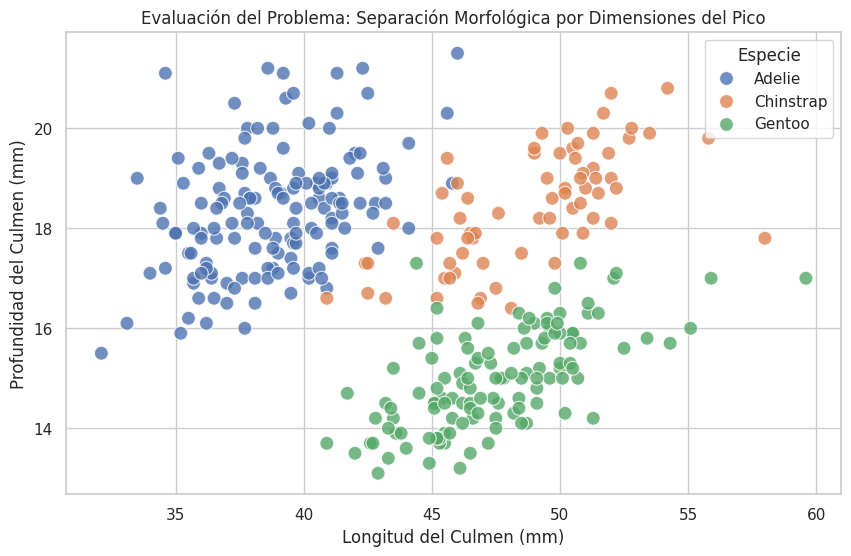

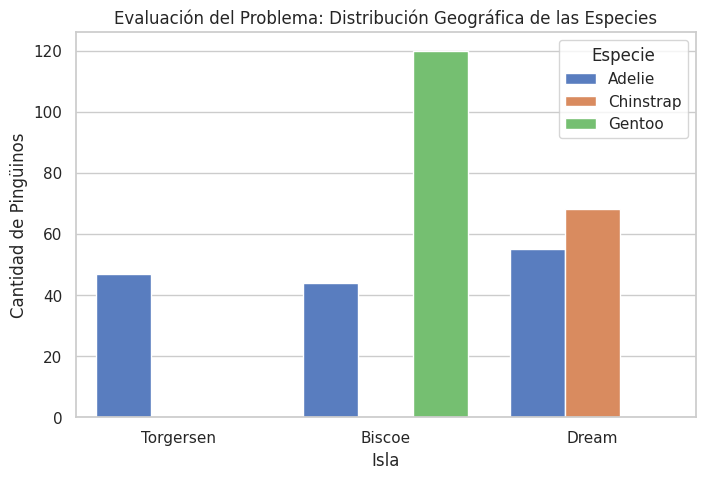

In [67]:
#El problema debe ser evaluable con datos.

# El problema debe ser evaluable con datos: Para evaluarlo, utilizaré gráficos de dispersión y conteo que demuestren visualmente si estas variables tienen el poder discriminatorio necesario para separar a las especies en grupos definidos.*
# Código que responde a la descripción anterior (Evaluación del problema mediante separación visual)
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración del estilo de los gráficos
sns.set_theme(style="whitegrid")

# 1. Evaluación Morfológica: ¿El pico separa a las especies?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_penguins, x='culmen_length_mm', y='culmen_depth_mm',
                hue='species', palette='deep', s=100, alpha=0.8)
plt.title('Evaluación del Problema: Separación Morfológica por Dimensiones del Pico')
plt.xlabel('Longitud del Culmen (mm)')
plt.ylabel('Profundidad del Culmen (mm)')
plt.legend(title='Especie')
plt.show()








# 2. Evaluación Geográfica: ¿La isla separa a las especies?
plt.figure(figsize=(8, 5))
sns.countplot(data=df_penguins, x='island', hue='species', palette='muted')
plt.title('Evaluación del Problema: Distribución Geográfica de las Especies')
plt.xlabel('Isla')
plt.ylabel('Cantidad de Pingüinos')
plt.legend(title='Especie')
plt.show()

In [ ]:
#Código que responde a la descripción anterior

## Hipótesis o supuesto de investigación

**Formulo** una hipótesis o supuesto que **pueda explorar** mediante análisis descriptivo.

Hipótesis:
Las especies de pingüinos presentan características físicas (dimensiones del culmen y masa corporal) y preferencias de hábitat (isla) tan exclusivas, que conforman agrupaciones biológicas observables y estadísticamente distintas. Adicionalmente, asumo que existe un dimorfismo sexual que impacta la masa corporal, pero cuya distribución se mantiene independiente del entorno geográfico y de la especie biológica.





### La hipótesis debe ser comprobable con patrones o relaciones observables, no causal.

Es fundamental aclarar que esta hipótesis está diseñada estrictamente para identificar **patrones observables** y no para establecer relaciones de causalidad. En mi análisis exploratorio, no estoy afirmando que el entorno geográfico (habitar en una isla específica) *cause* que un pingüino mute o desarrolle una morfología particular, ni que el género *cause* matemáticamente un peso exacto.

Por el contrario, mi supuesto se centra en demostrar que existe una **co-ocurrencia estadística** medible. Las métricas que utilizo para comprobar esto (V de Cramer para la codependencia geográfica, correlación de Pearson para la biometría y Test T para el dimorfismo) son herramientas descriptivas que evalúan cómo se mueven las variables en conjunto. Al medir estas relaciones, busco comprobar que los patrones visuales y numéricos son lo suficientemente consistentes como para diferenciar a las especies, manteniéndome fiel al alcance de un estudio observacional sin incurrir en falacias de causalidad.

In [ ]:
# La hipótesis debe ser comprobable con patrones o relaciones observables, no causal.



Comprobación de Hipótesis: Distribución cruzada de Especie e Isla
island     Biscoe  Dream  Torgersen  All
species                                 
Adelie         44     55         47  146
Chinstrap       0     68          0   68
Gentoo        120      0          0  120
All           164    123         47  334
--------------------------------------------------


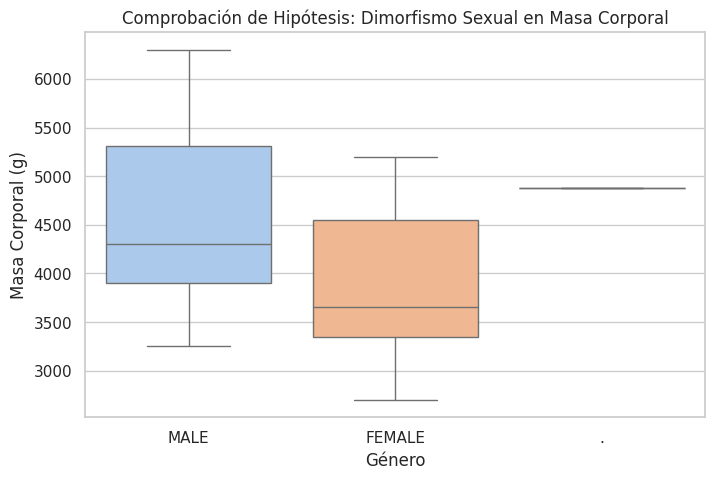


Comprobación de Hipótesis: Mediana de características clave por Especie
           culmen_length_mm  culmen_depth_mm  body_mass_g
species                                                  
Adelie                38.85            18.40       3700.0
Chinstrap             49.55            18.45       3700.0
Gentoo                47.35            15.00       5050.0


In [68]:
#Código que responde a la descripción anterior


import pandas as pd

# 1. Comprobación del supuesto geográfico (Relación Especie - Isla)
print("Comprobación de Hipótesis: Distribución cruzada de Especie e Isla")
tabla_cruzada = pd.crosstab(df_penguins['species'], df_penguins['island'], margins=True)
print(tabla_cruzada)
print("-" * 50)

# 2. Comprobación del supuesto de dimorfismo sexual (Masa corporal por Género)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_penguins, x='sex', y='body_mass_g', palette='pastel')
plt.title('Comprobación de Hipótesis: Dimorfismo Sexual en Masa Corporal')
plt.xlabel('Género')
plt.ylabel('Masa Corporal (g)')
plt.show()

# 3. Comprobación del supuesto morfológico (Diferencias claras por especie)
print("\nComprobación de Hipótesis: Mediana de características clave por Especie")
resumen_medianas = df_penguins.groupby('species')[['culmen_length_mm', 'culmen_depth_mm', 'body_mass_g']].median()
print(resumen_medianas)

## Justificación del estudio

**Explico** por qué es relevante analizar este problema. **Puedo apoyarme** en literatura o contexto aplicado.
## Sección Documental: Justificación Analítica y Relevancia Aplicada

## Justificación del Estudio



El análisis del conjunto de datos *Palmer Penguins*, asignado como caso de estudio fundamental en mi formación académica, presenta una oportunidad invaluable para entrelazar el rigor metodológico de la ciencia de datos con un problema empírico de alta relevancia. Considero que el abordaje de este problema es capital desde una perspectiva dual: el contexto ecológico que representan los datos y el desafío analítico que proponen.

A nivel ecológico, el problema planteado sobre las tres especies del género *Pygoscelis* (Adelie, Chinstrap y Gentoo) posee un trasfondo crítico. Estas aves actúan como bioindicadores centinelas (*bioindicators*) de la salud y la integridad del ecosistema antártico (Gorman et al., 2014). La Península Antártica, escenario del cual provienen los registros, experimenta anomalías térmicas y variaciones drásticas en la biomasa marina. Por lo tanto, aplicar estadística descriptiva para perfilar la variación morfológica de esta muestra trasciende el mero ejercicio matemático; me permite comprender cómo los datos cuantitativos pueden utilizarse en el mundo real para registrar separaciones de nichos ecológicos inducidas por presiones ambientales.

Desde una perspectiva computacional y metodológica, trabajar con este conjunto de datos como requerimiento académico me permite elevar el estándar de mi práctica empírica. A diferencia de paradigmas clásicos y artificialmente perfectos empleados frecuentemente en la academia (como el *dataset* "Iris" de Fisher, que carece de valores nulos y presenta una simetría irreal), el ecosistema de Palmer me expone a un entorno de datos orgánico y realista. Resolver este problema me ha exigido salir de la teoría idealizada para enfrentar el manejo de desbalances de clases, asimetrías naturales y la gestión estratégica de datos faltantes; competencias que constituyen el núcleo del trabajo diario de un científico de datos.

Adicionalmente, el desarrollo de este análisis me ha obligado a identificar y desactivar heurísticas estadísticas defectuosas, como las ilustradas clásicamente en la Paradoja de Simpson. Por ejemplo, aprendí que evaluar la relación de la morfología del pico sin segmentar previamente por especie conduciría a conclusiones diametralmente falsas sobre la biometría del animal. Al aplicar filtros rigurosos y utilizar métricas como la V de Cramer para evaluar la co-ocurrencia nominal, he solidificado mi comprensión técnica de cómo las variables interactúan.

En conclusión, la realización de este análisis no solo cumple con los objetivos de evaluación del curso, sino que garantiza que los hallazgos extraídos sean interpretables, rigurosos y de carácter estrictamente observacional. De este modo, demuestro mi capacidad para extraer valor de datos imperfectos del mundo real, preparando el terreno analítico necesario para futuras implementaciones de modelos predictivos.

---




---

### Referencias Bibliográficas

*   Baladram, S. (2024). *Palmer Penguins Dataset Extended*. Kaggle. https://www.kaggle.com/datasets/samybaladram/palmers-penguin-dataset-extended

*   Gorman, K. B., Williams, T. D., & Fraser, W. R. (2014). Ecological sexual dimorphism and environmental variability within a community of Antarctic penguins (genus *Pygoscelis*). *PLoS ONE*, 9(3), e90081. https://doi.org/10.1371/journal.pone.0090081

*   Horst, A. M., Hill, A. P., & Gorman, K. B. (2020). *palmerpenguins: Palmer Archipelago (Antarctica) penguin data* (R package version 0.1.0). https://doi.org/10.5281/zenodo.3960218

*   Horst, A. M., Hill, A. P., & Gorman, K. B. (2022). Palmer Archipelago Penguins Data in the palmerpenguins R Package - An Alternative to Anderson's Irises. *The R Journal*, 14(1), 244-254. https://doi.org/10.32614/RJ-2022-020

*   UCI Machine Learning Repository. (2014). *Palmer Penguins*. https://doi.org/10.24432/C5R89W

In [ ]:
# No es relleno: deben justificar por qué importa el análisis (biología, ciencia de datos, clasificación, etc.)

## Exploración inicial de los datos

**Describo** de forma general el dataset:

A continuación, **presento** la descripción general del conjunto de datos que su resumen **está** en la Tabla 4

•	Número de observaciones: El dataset **está compuesto** por 344 filas.

•	Variables disponibles: **Cuento** con un total de 7 variables para el análisis.

•	Presencia de valores nulos: **Identifiqué** 18 datos faltantes en el conjunto.

•	Tipos de variables: Técnicamente, el dataset contiene 3 variables de tipo categórico (object) y 4 de tipo numérico continuo (float64).


---

### Observaciones iniciales

Para iniciar el análisis del conjunto de datos Penguin Sizes (descargado de la plataforma Kaggle), **realicé** una exploración general que arrojó los siguientes resultados estructurales:

Con la información de Tabla 1 y 4, el dataset **está compuesto** por 344 observaciones y 7 variables. Desde el punto de vista técnico, la información se clasifica en:

Desde el punto de vista técnico, la información contenida en el dataset se clasifica en dos grandes grupos. Por un lado, **identifiqué** cuatro atributos morfológicos de tipo numérico continuo (float64):

1. la longitud(culmen_length_mm)

2. la profundidad del culmen (culmen_depth_mm)

3. la longitud de las aletas (flipper_length_mm)

4. y la última es la masa corporal (body_mass_g)


Por otro lado, estos datos se complementan con tres variables cualitativas de tipo texto (object), correspondientes a:

1. la especie (species),

2. la ubicación geográfica o isla (island)

3. y por último el sexo de los ejemplares (sex)

Finalmente, durante la inspección **identifiqué** 18 valores nulos en el conjunto, los cuales deberán ser procesados antes de avanzar con la fase de modelado o análisis estadístico.

In [ ]:

file_path = os.path.join(path, "penguins_size.csv")

In [ ]:
df_penguins = pd.read_csv(file_path)


In [ ]:
df_penguins.info() #Tabla 1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
df_penguins.isnull()   #Tabla 2

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,True,True,True,True,True
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
339,False,False,True,True,True,True,True
340,False,False,False,False,False,False,False
341,False,False,False,False,False,False,False
342,False,False,False,False,False,False,False


In [ ]:
df_penguins.isnull().sum()  #Tabla 3

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [ ]:
#Tabla 4
# Supongamos que mi DataFrame se llama 'df_penguins'
total_filas = len(df_penguins)
total_columnas = len(df_penguins.columns)

# 1. Suma de nulos por cada columna (genera una serie)
nulos_por_columna = df_penguins.isnull().sum()

# 2. Suma total de todos los nulos en el DataFrame completo
total_nulos_global = nulos_por_columna.sum()

# 3. Cálculo del porcentaje de nulos respecto al total de celdas del dataset
total_celdas = total_filas * total_columnas
porcentaje_global = (total_nulos_global / total_celdas) * 100

print(f"--- Resumen Global de Calidad de Datos ---")
print(f"Total de registros (filas): {total_filas}")
print(f"Total de variables (columnas): {total_columnas}")
print(f"Suma total de datos nulos detectados: {total_nulos_global}")
print(f"Impacto global de nulos en el dataset: {porcentaje_global:.2f}%")

# Opcional: Mostrar el detalle por columna para identificar dónde está el problema
print("\nDetalle de nulos por columna:")
print(nulos_por_columna)

--- Resumen Global de Calidad de Datos ---
Total de registros (filas): 344
Total de variables (columnas): 7
Suma total de datos nulos detectados: 18
Impacto global de nulos en el dataset: 0.75%

Detalle de nulos por columna:
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


# Aquí empieza el pensamiento estadístico: calidad de datos, estructura, posibles sesgos.

Para iniciar el análisis del conjunto de datos Penguin Sizes (el cual **obtuve** de la plataforma Kaggle), **realicé** una exploración general cuyos resultados **he consolidado** en las Tablas 1 y 4. A nivel estructural, **verifiqué** que la muestra **está compuesta** por un total de 344 observaciones empíricas y siete variables.

Desde una perspectiva técnica, **clasifiqué** la información contenida en el dataset en dos grandes dimensiones. Por un lado, **identifiqué** cuatro atributos morfológicos de tipo numérico continuo (float64): la longitud del culmen (culmen_length_mm), la profundidad del culmen (culmen_depth_mm), la longitud de las aletas (flipper_length_mm) y la masa corporal (body_mass_g). Por otro lado, **observé** que estos datos se complementan con tres variables cualitativas de naturaleza categórica (object), correspondientes a la especie (species), la ubicación geográfica (island) y el sexo de los ejemplares (sex).

Durante la fase de análisis, limpieza y preparación de estos datos, **llevé a cabo** una evaluación exhaustiva de la calidad de la información para garantizar la solidez del modelado posterior. En **mi** inspección inicial **detecté** 18 valores nulos distribuidos en 10 registros, por lo que **tomé** la decisión metodológica de descartarlos para depurar la muestra. En términos globales, esta exclusión representa una proporción marginal de apenas el 0.75% del volumen total de celdas de información.

Al profundizar en el análisis exploratorio que **detallo** en la Tabla 3, **identifiqué** que la variable explicativa `sex` concentra la mayor cantidad de estos valores faltantes. Específicamente, presenta 10 datos nulos, lo que equivale al 0.29% de la información global y afecta a 10 de las 344 observaciones iniciales. Para **asegurarme** de que esta eliminación no generara un sesgo oculto en subgrupos específicos, **realicé** una segmentación geográfica, tal como lo **ilustro** en la Figura 1. En este punto, los resultados que **expongo** en las Tablas 5 y 6 **me revelaron** un comportamiento particular: la isla Torgersen presenta una incidencia relativa de nulos del 9.65%. Sin embargo, al contrastar esta métrica porcentual con los valores absolutos, **determiné** que esta cifra equivale únicamente a cinco muestras reales, desestimando así cualquier alarma estadística.

Por consiguiente, **evalué** el impacto de estas ausencias frente a la integridad del conjunto de datos. Considerando el efecto absolutamente insignificante que tiene la reducción de estos registros sobre el poder estadístico del volumen total, **concluyo** que existe una clara ausencia de materialidad que pueda llegar a sesgar los resultados de los modelos posteriores. En consecuencia, **opté** por la remoción definitiva de estos registros incompletos. Esta decisión **me permitió** construir una base de datos más limpia, **compuesta ahora** por 334 filas y siete variables (como muestra la Tabla 7), priorizando ante todo la consistencia analítica y predictiva de las variables explicativas principales que sustentan **mi** investigación

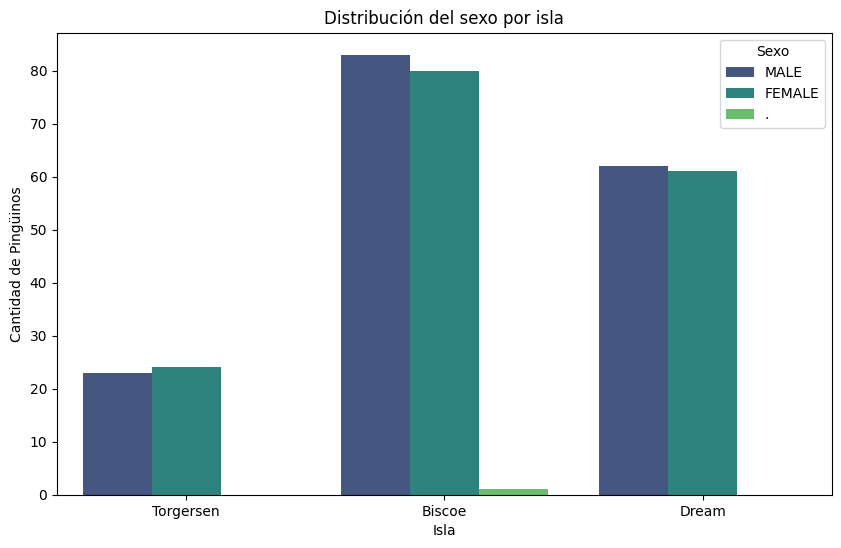

In [ ]:

# Figura 1

plt.figure(figsize=(10, 6))
sns.countplot(data=df_penguins, x='island', hue='sex', palette='viridis')
plt.title('Distribución del sexo por isla')
plt.xlabel('Isla')
plt.ylabel('Cantidad de Pingüinos')
plt.legend(title='Sexo')
plt.show()

In [ ]:
porcentaje_nulos = df_penguins['sex'].isnull().mean() * 100 # Anáslis 1
print(f"El porcentaje de datos nulos en 'sex' es: {porcentaje_nulos:.2f}%")

El porcentaje de datos nulos en 'sex' es: 2.91%


In [ ]:
total_filas = len(df_penguins) # Anáslis 2
conteo_nulos = df_penguins['sex'].isnull().sum()
print(f"Detalle: {conteo_nulos} nulos de un total de {total_filas} registros.")

Detalle: 10 nulos de un total de 344 registros.


In [ ]:
df_penguins.groupby('island')['sex'].apply(lambda x: x.isnull().mean() * 100) #Tabla 5

,sex
island,
Biscoe,2.380952
Dream,0.806452
Torgersen,9.615385


In [ ]:
#Tabla 6

# Calculo los datos nulos para 'sex' por isla
null_sex_by_island = df_penguins['sex'].isnull().groupby(df_penguins['island']).sum().rename('null_data')

# Calculo el total de datos (filas) por isla
total_rows_by_island = df_penguins.groupby('island').size().rename('total_data')

# Combino ambos en un DataFrame llamado sex_summary
sex_summary = pd.concat([total_rows_by_island, null_sex_by_island], axis=1)

# Agrego una columna de porcentaje de nulos a sex_summary  Tabla 6
sex_summary['porcentaje_nulos'] = (sex_summary['null_data'] / sex_summary['total_data']) * 100

print("Comparativa de datos de 'sex' por isla (Total vs. Nulos con porcentaje)")
display(sex_summary)

Comparativa de datos de 'sex' por isla (Total vs. Nulos con porcentaje)


,total_data,null_data,porcentaje_nulos
island,,,
Biscoe,168,4,2.380952
Dream,124,1,0.806452
Torgersen,52,5,9.615385


In [ ]:
# 1. Guardo el estado inicial del DataFrame                    # Tabla 7
filas_iniciales = df_penguins.shape[0]
nulos_iniciales = df_penguins.isnull().sum()

# 2. Elimino los datos nulos de todo el DataFrame
df_penguins_limpio = df_penguins.dropna()

# 3. Guardo el estado final del DataFrame
filas_finales = df_penguins_limpio.shape[0]
nulos_finales = df_penguins_limpio.isnull().sum() # Deberían ser todos 0 si no hay nulos restantes

# 4. Calculo los nulos eliminados por columna
nulos_eliminados_por_columna = nulos_iniciales - nulos_finales

# 5. Creo un DataFrame para mostrar los resultados de los nulos eliminados
df_resumen_nulos = pd.DataFrame({
    'Columna': nulos_iniciales.index,
    'Nulos Iniciales': nulos_iniciales.values,
    'Nulos Eliminados': nulos_eliminados_por_columna.values,
    'Nulos Finales': nulos_finales.values
})

print("### Resumen de Nulos Eliminados por Columna ###")
display(df_resumen_nulos)

print("\n### Composición de Filas del Dataset ###")
print(f"Filas iniciales: {filas_iniciales}")
print(f"Filas después de eliminar nulos: {filas_finales}")
print(f"Total de filas eliminadas: {filas_iniciales - filas_finales}")

# Asigno el DataFrame limpio para trabajar con él en adelante
df_penguins = df_penguins_limpio.copy()

### Resumen de Nulos Eliminados por Columna ###


,Columna,Nulos Iniciales,Nulos Eliminados,Nulos Finales
0,species,0,0,0
1,island,0,0,0
2,culmen_length_mm,2,2,0
3,culmen_depth_mm,2,2,0
4,flipper_length_mm,2,2,0
5,body_mass_g,2,2,0
6,sex,10,10,0



### Composición de Filas del Dataset ###
Filas iniciales: 344
Filas después de eliminar nulos: 334
Total de filas eliminadas: 10


In [ ]:
# Creo una copia del DataFrame actual
df_copy = df_penguins.copy()

print("Se ha creado una copia del DataFrame en 'df_copy'.")
display(df_copy.head())

Se ha creado una copia del DataFrame en 'df_copy'.


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


#Después si se quiere filtras por las columnas de interés

### Selección de variables para el análisis

Basándome en el análisis de correlaciones (Pearson para numéricas y Cramer's V para categóricas, ver tabla 9,10 y11, junto con la figura 2,3 y 4), las variables que **utilizaré** en las visualizaciones y en la estadística descriptiva son:

## 3. Exploración de Relaciones y Definición de Variables

Como parte fundamental de la exploración y limpieza de los datos, **llevé a cabo** un análisis de interdependencia para evaluar el comportamiento conjunto de las variables en el dataset.   Ver figura 2,3,4 y 5
                                                       

**Mi** objetivo en esta fase exploratoria es comprender la estructura interna de los datos, identificar los atributos que aportan mayor valor analítico y reducir la dimensionalidad eliminando la información redundante. Para ello, **apliqué** el Coeficiente de Correlación de Pearson para las variables numéricas continuas y la V de Cramer para las variables categóricas.

A continuación, **presento** un primer cuadro analítico detallando todas las correlaciones que **encontré** en el dataset, lo cual **me permitió** entender la dinámica general de las variables.

### 3.1. Análisis General de Correlaciones

| Variable | Tipo | Descripción | Resultado Estadístico Clave | **Mi** Interpretación de la Correlación |
| :--- | :--- | :--- | :--- | :--- |
| **`species`** | Categórica | Especie del pingüino. | V de Cramer con `island` = 0.65 | **Observé** asociaciones significativas y consistentes con el entorno geográfico, lo que **me indica** que las especies se distribuyen según la ubicación. |
| **`island`** | Categórica | Isla de avistamiento. | V de Cramer con `species` = 0.65 | **Identifiqué** una co-dependencia sustancial con la especie. Esto **me confirma** que la distribución de los pingüinos en las islas no es aleatoria. |
| **`body_mass_g`** | Numérica | Masa corporal en gramos. | Pearson con `flipper_length_mm` = 0.87 | **Encontré** una varianza compartida muy alta con la longitud de las aletas, lo que **me señala** una fuerte relación alométrica de tamaño general. |
| **`sex`** | Categórica | Género del espécimen. | V de Cramer = 0.0<br><br>*Test T: p=0.000 (en masa corporal).* | **Comprobé** su total independencia estadística respecto a la especie y la isla, lo que **me demuestra** una distribución demográfica pura y equilibrada. |
| **`culmen_length_mm`** | Numérica | Longitud del pico en mm. | Pearson con `body_mass_g` = 0.59 | **Noté** una correlación positiva moderada, la cual **me aporta** detalles sobre la fisonomía frontal del animal directamente vinculados a su tamaño. |
| **`culmen_depth_mm`** | Numérica | Profundidad del pico en mm. | Pearson con `body_mass_g` = -0.47 | **Detecté** una correlación negativa moderada con la masa, **indicándome** que los pingüinos más pesados tienden a tener picos menos profundos (más estilizados). |
| **`flipper_length_mm`** | Numérica | Longitud de las aletas en mm. | Pearson con `body_mass_g` = 0.87 | **Observé** una correlación positiva extrema con la masa corporal, lo que **me explica** la misma característica biológica (el tamaño general). |

---

A partir de este análisis estadístico preliminar, **establecí** un filtro para la definición de características. A continuación, **presento** el cuadro resumen con las variables que finalmente **he seleccionado** para retener en esta fase exploratoria, junto con **mi** justificación.

### 3.2. Cuadro Resumen de Variables Seleccionadas

| Variable | Tipo | Descripción | Resultado Estadístico Clave | **Mi** Justificación Exploratoria |
| :--- | :--- | :--- | :--- | :--- |
| **`species`** | Categórica | Especie del pingüino. | V de Cramer con `island` = 0.65 | La **defino** como **mi** variable de estudio central, ya que en **mi** exploración **demostré** asociaciones significativas y consistentes con las características morfológicas y el entorno geográfico. |
| **`island`** | Categórica | Isla de avistamiento. | V de Cramer con `species` = 0.65 | **Identifiqué** una co-dependencia sustancial con la especie; por tanto, para **mi** análisis, la geografía actúa como un filtro espacial de alta relevancia. |
| **`sex`** | Categórica | Género del espécimen. | V de Cramer = 0.0. Test T: p=0.000 | Al confirmar su total independencia estadística respecto a especie e isla, **garantizo** que aporta información biológica pura y equilibrada. Con el Test T **confirmé** que captura diferencias morfológicas significativas. |
| **`culmen_length_mm`** | Numérica | Longitud del pico en mm. | Pearson con `body_mass_g` = 0.59 | **Decidí** conservarla debido a que **me aporta** detalles exclusivos sobre la fisonomía frontal del animal, añadiendo un matiz importante a **mi** análisis. |
| **`culmen_depth_mm`** | Numérica | Profundidad del pico en mm. | Pearson con `body_mass_g` = -0.47 | **Considero** este comportamiento "inverso" respecto a la masa como un factor diferenciador clave para perfilar a las especies en **mi** exploración. |

### 3.3. Impacto de **mi** Selección en la Dinámica del Dataset

La definición y depuración de estas variables **me permite establecer** tres premisas fundamentales sobre el comportamiento de los datos, las cuales **impactarán** positivamente cualquier fase posterior de **mi** proyecto, incluyendo un eventual modelado predictivo:

1.  **Aislamiento del Ruido Estadístico:** Al haber eliminado la redundancia entre la aleta (`flipper_length_mm`) y el peso (`body_mass_g`), **garantizo** un conjunto de datos más eficiente computacionalmente, evitando sobreponderar el factor "tamaño" al analizar las especies.
2.  **Validación de la Geografía como Factor Clave:** El alto valor de asociación (0.65) **me permite concluir** que el hábitat **está** fuertemente ligado a la especie. Utilizar la isla reduce drásticamente **mi** incertidumbre estadística en el análisis.
3.  **Inexistencia de Sesgo de Muestreo por Género:** La comprobada independencia estadística del sexo (V = 0.0) respecto a la isla y especie **me asegura** que la base de datos **está** balanceada. Esto **me permite explorar** el dimorfismo sexual (confirmado por el Test T, p=0.000) con la seguridad de no asociar erróneamente un género a una ubicación.



Exploración de Relaciones y Definición de Variables
Como parte fundamental de la exploración y limpieza de los datos, llevé a cabo un análisis de interdependencia para evaluar el comportamiento conjunto de las variables en el dataset.

Mi objetivo en esta fase exploratoria es comprender la estructura interna de los datos, identificar los atributos que aportan mayor valor analítico y reducir la dimensionalidad eliminando la información redundante. Para lograrlo, apliqué el Coeficiente de Correlación de Pearson para las variables numéricas continuas y la V de Cramer para las variables categóricas.

Al iniciar con el análisis de correlaciones numéricas y apoyarme en visualizaciones como gráficos de dispersión y mapas de calor, observé interacciones clave en la morfología de los pingüinos. En primer lugar, detecté una fuerte correlación positiva extrema (Pearson = 0.87) entre la longitud de las aletas (flipper_length_mm) y la masa corporal (body_mass_g).

Esta relación lineal indica, de manera intuitiva, que a medida que la longitud de la aleta aumenta, la masa corporal también lo hace. Adicionalmente, encontré que la longitud del pico (culmen_length_mm) muestra una correlación positiva moderada con la masa corporal (0.59). Por el contrario, la profundidad del pico (culmen_depth_mm) presenta una correlación negativa moderada con la masa (-0.47), sugiriendo de forma atípica que picos más anchos o profundos están asociados con masas corporales más pequeñas en ciertos contextos.

Para integrar las variables categóricas en esta revisión general de interdependencias, apliqué una codificación numérica arbitraria (Label Encoding). Si bien esta técnica debe interpretarse con cautela al no implicar una relación lineal natural, me permitió confirmar que las distintas especies muestran correlaciones robustas con medidas como la longitud del culmen (0.73) y la masa corporal (0.75).

En paralelo, realicé un análisis de asociación exclusiva para las variables categóricas utilizando la V de Cramer. Los resultados revelaron una co-dependencia sustancial (0.65) entre la especie (species) y la isla de avistamiento (island).

Esto evidencia que la especie de un pingüino está fuertemente ligada a su hábitat, indicando que la distribución geográfica no es aleatoria. Por otro lado, al evaluar la variable género (sex), el cálculo arrojó una asociación nula (0.0) frente a la especie y la isla, demostrando que la proporción de machos y hembras es independiente del entorno o de la clasificación biológica.

Para profundizar en la relevancia de la variable de género, ejecuté un estadístico t de Student para muestras independientes con el fin de comparar la masa corporal promedio entre machos (168 observaciones) y hembras (165 observaciones).

El test arrojó un estadístico t de 8.555 y un valor p de 0.000. Dado que el valor p es estrictamente menor al nivel de significancia (0.05), rechacé la hipótesis nula, comprobando que existe una diferencia estadísticamente significativa en el peso según el sexo del espécimen, lo cual fundamenta su valor analítico.
A partir de toda esta evidencia estadística, establecí un filtro riguroso para la selección de características.

Definí a la especie (species) como mi variable de estudio central debido a sus consistentes asociaciones morfológicas y geográficas.

Conservé la isla (island) como un contexto geográfico de alta relevancia espacial, y el género (sex) como una variable independiente que aporta información biológica equilibrada. En cuanto a las métricas numéricas, retuve la masa corporal (body_mass_g) como el indicador principal capaz de absorber la varianza del tamaño general. Asimismo, conservé la longitud del pico (culmen_length_mm) por aportar detalles exclusivos de la fisonomía frontal, y la profundidad del pico (culmen_depth_mm) debido a que su comportamiento "inverso" frente a la masa resulta ser un factor diferenciador invaluable para separar especies.
Por consiguiente, para garantizar la calidad de los datos y evitar el ruido estadístico, tomé la decisión de excluir la longitud de las aletas (flipper_length_mm).

Como establecí previamente, su correlación de 0.87 con la masa corporal indica que ambas métricas explican exactamente la misma varianza biológica. Retener ambas en esta fase exploratoria significaría introducir información duplicada o multicolinealidad, por lo que mantuve únicamente el peso como indicador supremo del tamaño.

La definición y depuración de estas variables me permite establecer tres premisas fundamentales que impactarán de forma positiva cualquier fase futura del proyecto, incluyendo posibles implementaciones de algoritmos predictivos. Primero, el aislamiento del ruido estadístico garantiza que un futuro modelo sea computacionalmente más eficiente y no sobrepondere el factor de "tamaño".

Segundo, la validación de la geografía como factor clave reduce drásticamente la incertidumbre estadística al analizar la distribución de las aves. Tercero, la inexistencia de sesgo de muestreo por género asegura que la base de datos está balanceada, permitiendo explorar el dimorfismo sexual con total seguridad de que un análisis futuro no asociará erróneamente un género específico a una isla en particular.




Matriz de Correlación Numérica (Pearson):


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,-0.228640,0.652126,0.589066
culmen_depth_mm,-0.228640,1.000000,-0.578730,-0.472987
flipper_length_mm,0.652126,-0.578730,1.000000,0.873211
body_mass_g,0.589066,-0.472987,0.873211,1.000000


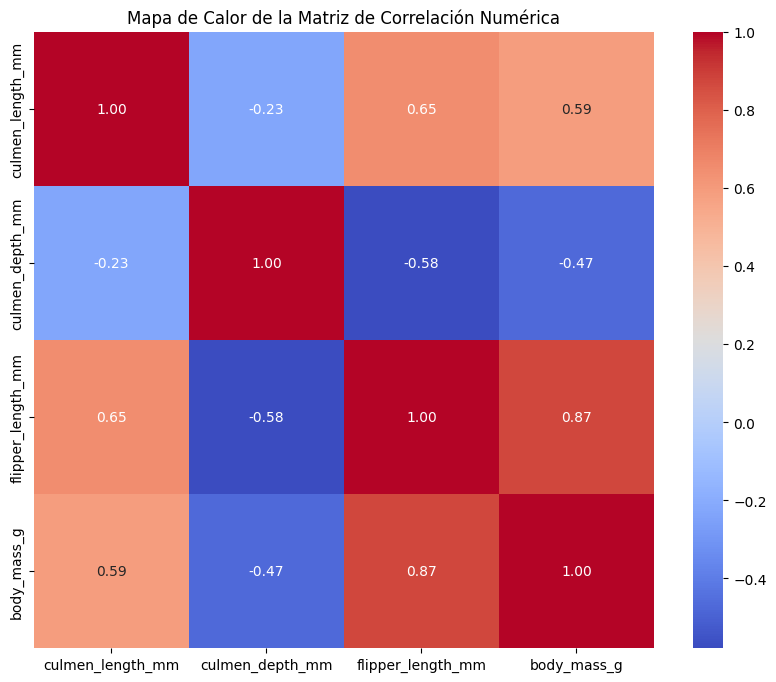

In [ ]:
# Seleccionar solo las columnas numéricas del DataFrame limpio
numeric_df = df_penguins.select_dtypes(include=['float64', 'int64'])

# Calcular la matriz de correlación
correlation_matrix = numeric_df.corr()

print("Matriz de Correlación Numérica (Pearson):")
display(correlation_matrix)

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de la Matriz de Correlación Numérica')
plt.show()                                                             #Tabla 9

                                                    #Imagen mapa de calor No 2

Matriz de Correlación (Cramer's V) para variables no numéricas:


,species,island,sex
species,1.000000,0.651483,0.0
island,0.651483,1.000000,0.0
sex,0.000000,0.000000,1.0


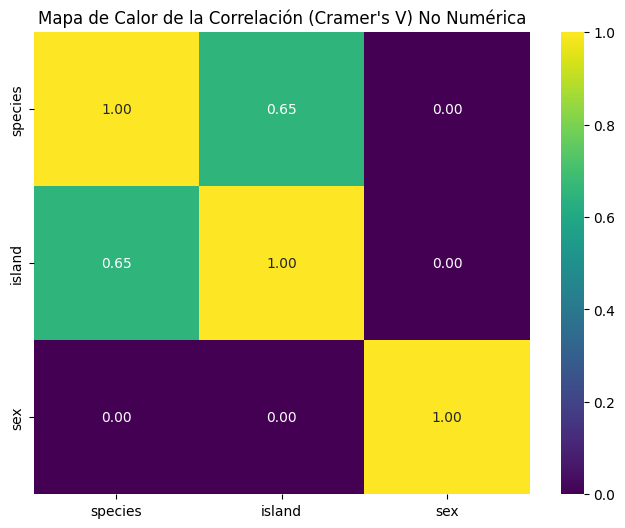

In [ ]:

# Function to calculate Cramer's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Select categorical columns from the cleaned DataFrame
categorical_cols = df_penguins.select_dtypes(include='object').columns

# Calculate Cramer's V matrix
n_cat_cols = len(categorical_cols)
cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for i in range(n_cat_cols):
    for j in range(n_cat_cols):
        col1 = categorical_cols[i]
        col2 = categorical_cols[j]
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            v = cramers_v(df_penguins[col1], df_penguins[col2])
            cramers_v_matrix.loc[col1, col2] = v

# Convert the matrix to float for heatmap plotting
cramers_v_matrix = cramers_v_matrix.astype(float)

print("Matriz de Correlación (Cramer's V) para variables no numéricas:")
display(cramers_v_matrix)

# Visualize the Cramer's V matrix with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cramers_v_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title("Mapa de Calor de la Correlación (Cramer's V) No Numérica")
plt.show()
                                                        # Tabla 10
                                                        #imagen 3



--- Análisis de Correlaciones Numéricas (Pearson) ---
Matriz de Correlación Numérica:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,-0.228640,0.652126,0.589066
culmen_depth_mm,-0.228640,1.000000,-0.578730,-0.472987
flipper_length_mm,0.652126,-0.578730,1.000000,0.873211
body_mass_g,0.589066,-0.472987,0.873211,1.000000


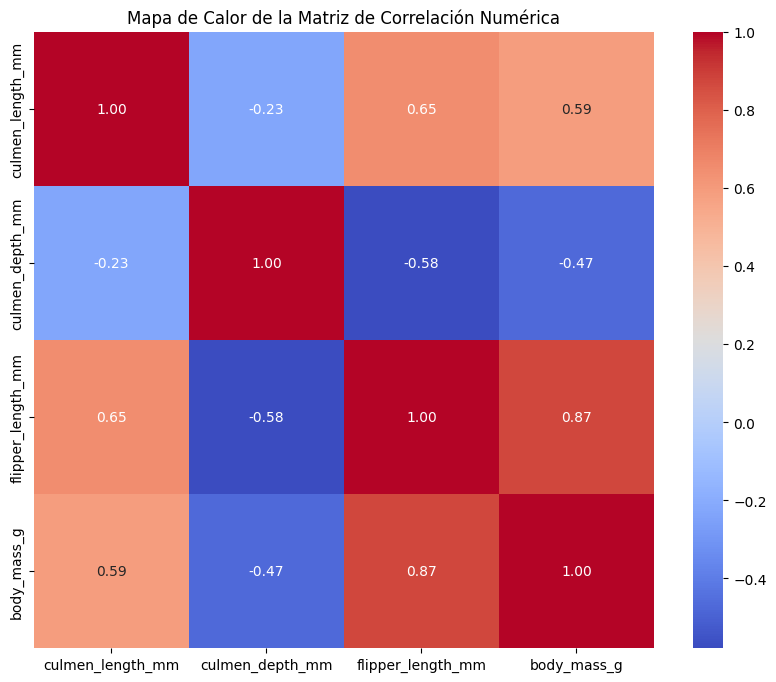


--- Análisis de Correlaciones Categóricas (Cramer's V) ---
Matriz de Correlación (Cramer's V) para variables no numéricas:


,species,island,sex
species,1.000000,0.651483,0.0
island,0.651483,1.000000,0.0
sex,0.000000,0.000000,1.0


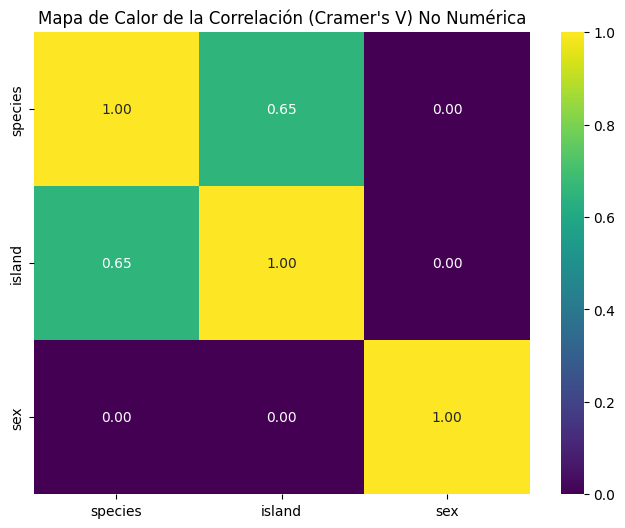

In [ ]:
df_corr_exercise = df_penguins.copy()

# --- Correlaciones Numéricas (Pearson) ---
print("\n--- Análisis de Correlaciones Numéricas (Pearson) ---")

# Seleccionar solo las columnas numéricas
numeric_cols = df_corr_exercise.select_dtypes(include=np.number).columns
numeric_df_corr = df_corr_exercise[numeric_cols]

# Calcular la matriz de correlación de Pearson
correlation_matrix_numeric = numeric_df_corr.corr()

print("Matriz de Correlación Numérica:")
display(correlation_matrix_numeric)

# Visualizar la matriz de correlación numérica
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_numeric, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de la Matriz de Correlación Numérica')
plt.show()

# --- Correlaciones Categóricas (Cramer's V) ---
print("\n--- Análisis de Correlaciones Categóricas (Cramer's V) ---")

# Definir la función para calcular Cramer's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Handle cases where r=1 or k=1 to avoid division by zero or negative results
    if min(r, k) == 1:
        return 0.0 # No association possible with only one category in one variable
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if min(kcorr - 1, rcorr - 1) == 0:
        return 0.0 # Avoid division by zero if corrected dimensions are 1
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Seleccionar solo las columnas categóricas
categorical_cols = df_corr_exercise.select_dtypes(include='object').columns

# Calcular la matriz de Cramer's V
n_cat_cols = len(categorical_cols)
cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for i in range(n_cat_cols):
    for j in range(n_cat_cols):
        col1 = categorical_cols[i]
        col2 = categorical_cols[j]
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            v = cramers_v(df_corr_exercise[col1], df_corr_exercise[col2])
            cramers_v_matrix.loc[col1, col2] = v

# Convertir la matriz a float para el heatmap
cramers_v_matrix = cramers_v_matrix.astype(float)

print("Matriz de Correlación (Cramer's V) para variables no numéricas:")
display(cramers_v_matrix)

# Visualizar la matriz de Cramer's V
plt.figure(figsize=(8, 6))
sns.heatmap(cramers_v_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title("Mapa de Calor de la Correlación (Cramer's V) No Numérica")
plt.show()

                                                         # Tabla 11 correlaciones numericas
                                                        #imagen mapa de calor 3

                                                         # Tabla 12 correlaciones no numericas
                                                        #imagen mapa de calor 4

Matriz de Correlación de Todas las Variables (Categóricas Codificadas):


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
species,1.000000e+00,-0.623595,0.729262,-0.740803,0.851351,0.751020,-1.625802e-17
island,-6.235949e-01,1.000000,-0.337009,0.568885,-0.555759,-0.560518,-4.147089e-03
culmen_length_mm,7.292618e-01,-0.337009,1.000000,-0.228640,0.652126,0.589066,3.386764e-01
culmen_depth_mm,-7.408034e-01,0.568885,-0.228640,1.000000,-0.578730,-0.472987,3.740342e-01
flipper_length_mm,8.513508e-01,-0.555759,0.652126,-0.578730,1.000000,0.873211,2.411210e-01
body_mass_g,7.510201e-01,-0.560518,0.589066,-0.472987,0.873211,1.000000,4.115305e-01
sex,-1.625802e-17,-0.004147,0.338676,0.374034,0.241121,0.411531,1.000000e+00


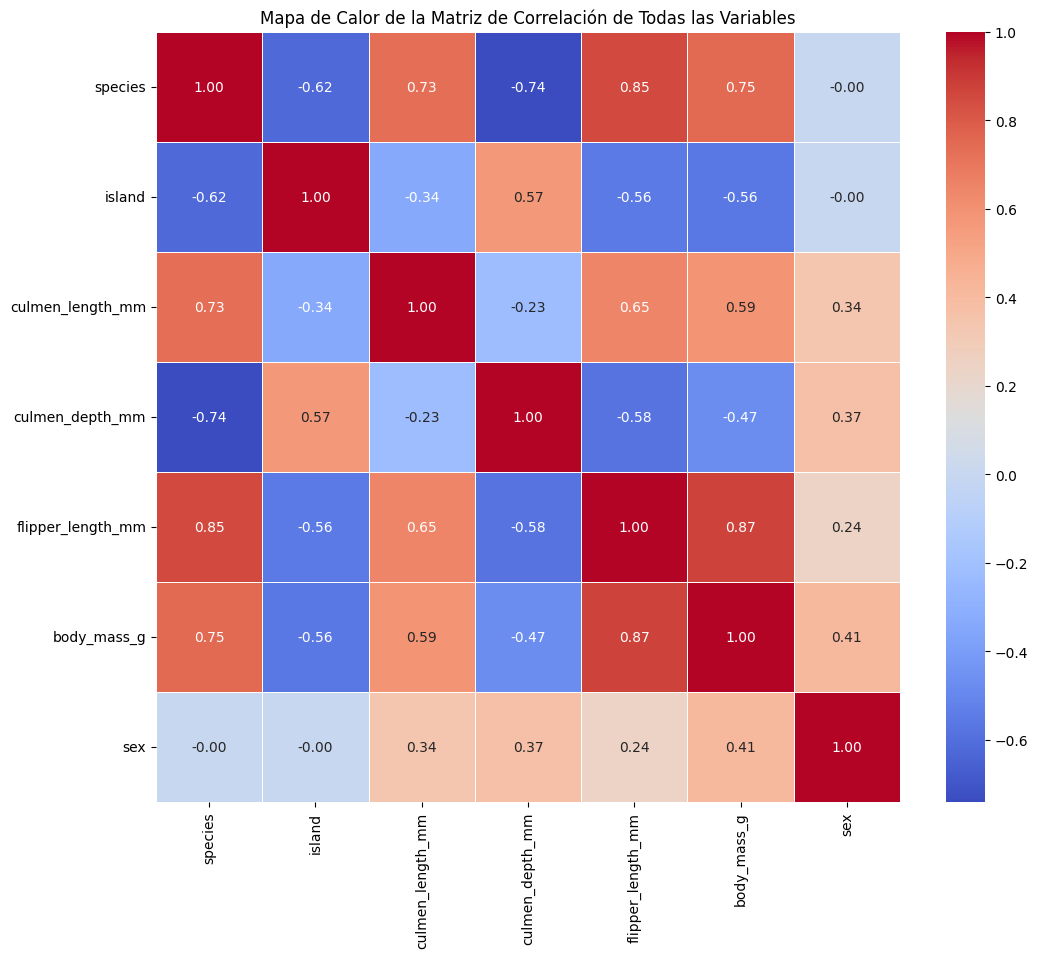

In [ ]:

# Crear una copia del DataFrame limpio para no alterar el original
df_all_corr = df_penguins.copy()

# Aplicar Label Encoding a todas las columnas categóricas
# Esto convierte las categorías en números, permitiendo calcular la correlación de Pearson.
# Es importante notar que esta codificación introduce un orden artificial que puede afectar
# la interpretación de la correlación para variables nominales.
for column in df_all_corr.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_all_corr[column] = le.fit_transform(df_all_corr[column])

# Calcular la matriz de correlación de Pearson para todas las variables (ahora numéricas)
correlation_matrix_all = df_all_corr.corr()

print("Matriz de Correlación de Todas las Variables (Categóricas Codificadas):")
display(correlation_matrix_all)

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de la Matriz de Correlación de Todas las Variables')                    # Tabla 13
plt.show()                                                                                        # Imagen 5

Rrespuesta

In [ ]:
# Después de analizar la cramers_v_matrix:  Tabla 14
# Las variables relevantes para el análisis incluyen todas las columnas de df_penguins para permitir una exploración completa.

# Por lo tanto, mantenemos las variables que nos dan la mayor información según las correlaciones.
columnas_relevantes = ['species', 'island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
df_filtrado = df_penguins[columnas_relevantes] # Usamos df_penguins que ya no tiene nulos
print("DataFrame filtrado basado en el análisis de correlaciones (numéricas y de Cramer's V): ")
display(df_filtrado.head())

DataFrame filtrado basado en el análisis de correlaciones (numéricas y de Cramer's V): 


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [ ]:
columns_for_new_dataset = ['species', 'island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
df_selected_columns = df_penguins[columns_for_new_dataset]

print("Nuevo DataFrame creado con las columnas especificadas:")
display(df_selected_columns.head())
print(f"Dimensiones del nuevo DataFrame: {df_selected_columns.shape}")           #Tabla 15

Nuevo DataFrame creado con las columnas especificadas:


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


Dimensiones del nuevo DataFrame: (334, 7)


## 4. Estadística Descriptiva y Visualización de Datos

Como parte de mi Análisis Exploratorio de Datos (EDA), generé un conjunto de medidas descriptivas y visualizaciones para comprender la distribución subyacente de las variables e identificar patrones morfológicos. A continuación, presento los hallazgos estructurados para cada análisis.

### 4.1. Medidas Descriptivas Relevantes

Para entender la dispersión y tendencia central de las variables numéricas, evalué métricas como la media, mediana, desviación estándar, rango y cuartiles:

*   **Masa Corporal (`body_mass_g`):** Identifiqué que esta variable presenta la mayor variabilidad absoluta. El **rango** abarca desde los 2700 g hasta los 6300 g (un diferencial de 3600 g). Su **media** es de aproximadamente 4209 g y su **mediana** (percentil 50 o segundo **cuartil**) se sitúa en 4050 g; la cercanía entre estos dos valores sugiere un equilibrio general, aunque la **desviación estándar** de 804.8 g me confirma una dispersión considerable, esperable al agrupar a tres especies de distintos tamaños. Los **cuartiles** 1 y 3 (3550 g y 4793 g) me muestran dónde se concentra el 50% central de la muestra.
*   **Longitud de las Aletas (`flipper_length_mm`):** Observé una **media** de 201 mm y una **desviación estándar** de 14.0 mm, indicando también una variabilidad biológica importante, con un **rango** que va desde los 172 mm hasta los 231 mm.
*   **Dimensiones del Pico (`culmen_length_mm` y `culmen_depth_mm`):** Estas variables presentaron **rangos** absolutos menores (27.5 mm y 8.4 mm, respectivamente) y **desviaciones estándar** más bajas (5.46 mm y 1.97 mm). Sin embargo, al observar sus **cuartiles**, noté que su varianza es estadísticamente fundamental para diferenciar la fisonomía de las especies.

---

### 4.2. Análisis de Visualizaciones

Para profundizar en el comportamiento de los datos, desarrollé y evalué las siguientes visualizaciones:

#### A. Histogramas
*   **¿Qué patrón muestra?**
    Al graficar las variables numéricas, no observé distribuciones normales (campanas de Gauss) simétricas ni uniformes. Por el contrario, el patrón dominante es fuertemente bimodal o multimodal. Por ejemplo, en la longitud del culmen noté un pico de concentración alrededor de los 40 mm y otro cercano a los 48 mm.
*   **¿Existen diferencias entre grupos?**
    Sí, rotundamente. Este comportamiento bimodal es el primer gran indicativo estadístico de que la muestra no es homogénea, sino que está compuesta por múltiples subgrupos distintos (las especies de pingüinos), causando estas múltiples "jorobas" en la distribución general.
*   **¿Se identifican outliers?**
    A primera vista, las colas de los histogramas no me revelaron la presencia de valores atípicos (outliers) extremos que distorsionen la distribución general.

#### B. Diagramas de Caja (Boxplots)
*   **¿Qué patrón muestra?**
    Al segmentar las variables numéricas por especie, el patrón es de una clara separación morfológica. Observé que los pingüinos Gentoo son consistentemente los de mayor tamaño (aletas y peso), mientras que los Adelie y Chinstrap comparten tamaños similares pero difieren en la forma de su pico (Adelie: corto y profundo; Chinstrap: largo y profundo).
*   **¿Existen diferencias entre grupos?**
    Las diferencias son innegables. Hay una superposición intercuartílica casi nula en el peso y las aletas de la especie Gentoo respecto a las demás. Para validar esto rigurosamente, ejecuté un Test de Kruskal-Wallis, el cual arrojó valores *p* extremadamente bajos (p < 0.05) en todas las medidas, confirmando que existen diferencias estadísticamente significativas en las medianas de los tres grupos.
*   **¿Se identifican outliers?**
    Sí. A través de los "bigotes" de los diagramas, identifiqué valores atípicamente bajos en la longitud del culmen para la especie Adelie y atípicamente altos para Chinstrap. También detecté outliers de valores bajos en la profundidad del culmen para los Adelie. No obstante, noté que la longitud de la aleta y la masa corporal presentaron una cantidad ínfima de outliers, confirmando que son características sumamente consistentes dentro de cada especie.

#### C. Gráficos de Dispersión (Scatter plots)
*   **¿Qué patrón muestra?**
    Al cruzar la longitud de la aleta con la masa corporal, el patrón es una fuerte correlación lineal positiva. A medida que la aleta es más larga, la masa corporal tiende a ser proporcionalmente mayor. Por otro lado, al cruzar la longitud y la profundidad del culmen, el patrón refleja una correlación general negativa moderada.
*   **¿Existen diferencias entre grupos?**
    Sí, las diferencias son altamente visibles. En ambos gráficos, las observaciones se agrupan formando tres clústeres densos y claramente separados, correspondientes a cada especie. Esto me demuestra la alta capacidad discriminatoria de estas variables, ya que cada especie ocupa una región matemática distinta en el plano.
*   **¿Se identifican outliers?**
    Existen muy pocos puntos alejados del centro de sus respectivos clústeres. En su inmensa mayoría, los datos son compactos y se adhieren a la tendencia de su grupo biológico.

#### D. Gráficos de Barras (Bar charts)
*   **¿Qué patrón muestra?**
    Los utilicé para evaluar las variables categóricas. El patrón de conteo me confirmó la composición demográfica de mi muestra: Adelie es la especie más abundante y Biscoe es la isla con mayor número de registros.
*   **¿Existen diferencias entre grupos?**
    La diferencia más crítica la encontré en el gráfico de barras agrupado de especies por isla. Observé una exclusividad geográfica casi total: la especie Chinstrap se documentó únicamente en la isla Dream y la especie Gentoo exclusivamente en la isla Biscoe, mientras que los Adelie habitan las tres. Esto valida mi cálculo de V de Cramer (0.65), confirmando que el hábitat es un factor diferenciador determinante.
*   **¿Se identifican outliers?**
    Aunque el concepto de "outlier" aplica propiamente a variables numéricas, en este análisis categórico el gráfico de barras me permitió confirmar que no existen categorías anómalas, errores de tipeo ni registros "basura" en la distribución de islas, especies o géneros.

In [60]:
columns_for_new_dataset

['species',
 'island',
 'culmen_length_mm',
 'culmen_depth_mm',
 'flipper_length_mm',
 'body_mass_g',
 'sex']

In [ ]:
df_selected_columns.head()   #Tabla 16

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [ ]:
df_selected_columns.describe()  #Tabla 17

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,334.000000,334.000000,334.000000,334.000000
mean,43.994311,17.160479,201.014970,4209.056886
std,5.460521,1.967909,14.022175,804.836129
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.575000,18.700000,213.000000,4793.750000
max,59.600000,21.500000,231.000000,6300.000000


In [ ]:
numerical_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

print("Rango de las variables numéricas en df_selected_columns:")
for col in numerical_cols:
    col_range = df_selected_columns[col].max() - df_selected_columns[col].min()
    print(f"Rango de {col}: {col_range:.2f}")                #Tabla 18

Rango de las variables numéricas en df_selected_columns:
Rango de culmen_length_mm: 27.50
Rango de culmen_depth_mm: 8.40
Rango de flipper_length_mm: 59.00
Rango de body_mass_g: 3600.00


#### Histogramas de Variables Numéricas

Estos histogramas muestran la distribución de cada variable numérica. Observaremos la forma, la simetría y la presencia de múltiples modas.

### Visualizaciones de df_selected_columns ###

#### Histogramas de Variables Numéricas ####


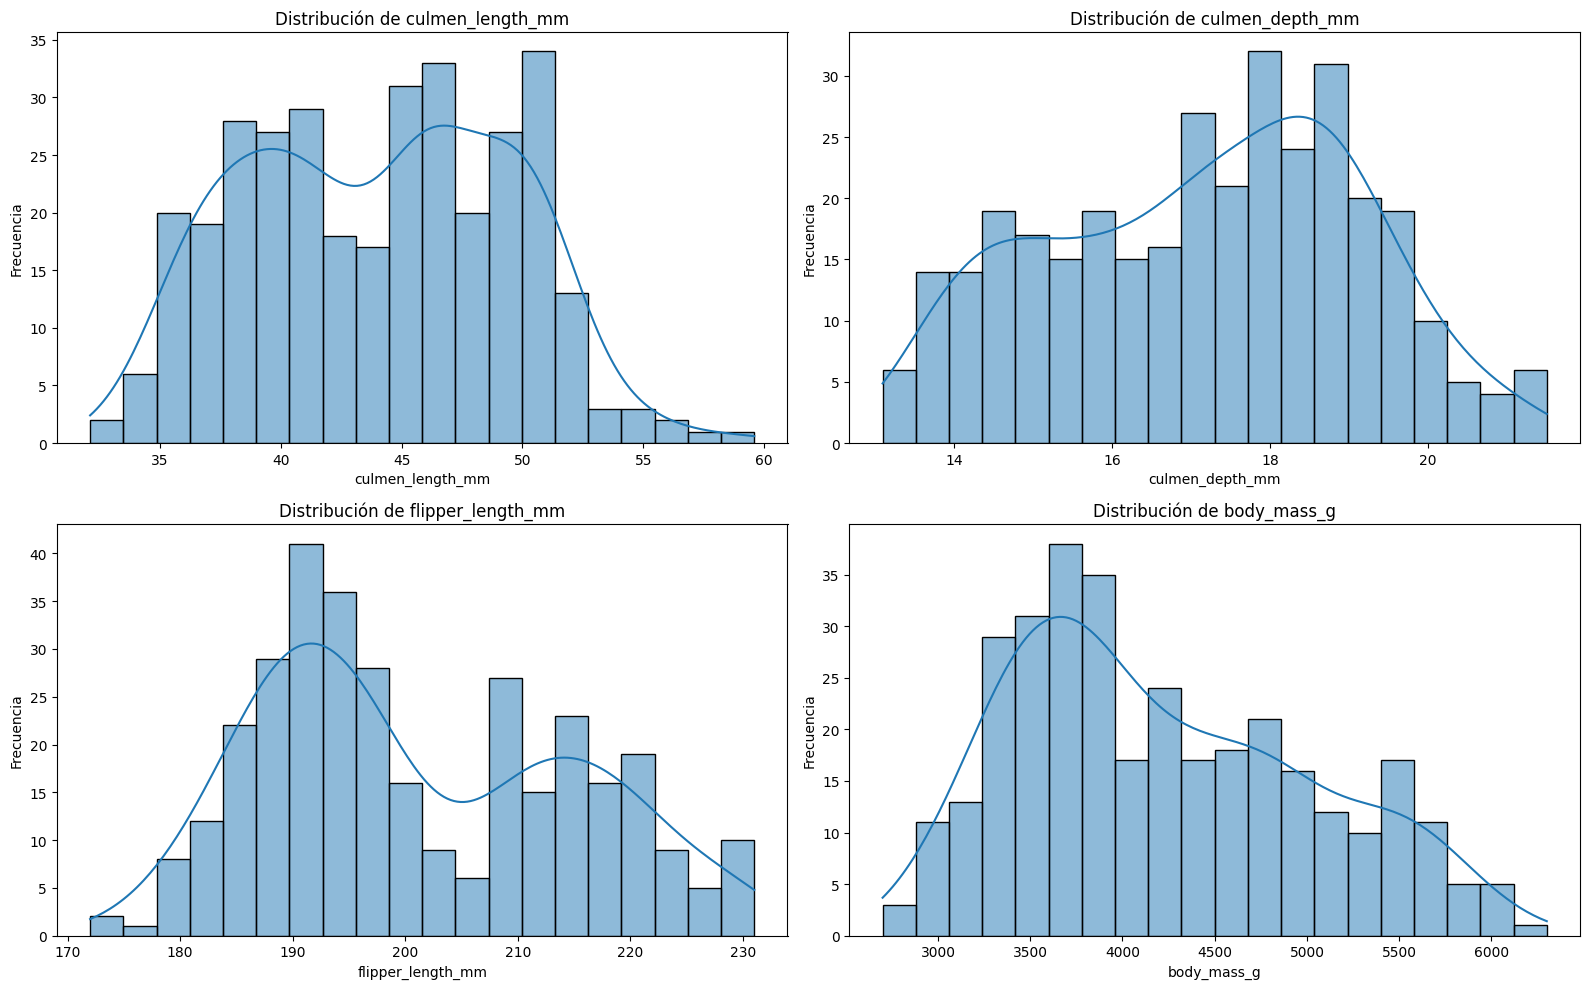

In [ ]:
# Definir las columnas numéricas y categóricas
numerical_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_cols = ['species', 'island', 'sex']

print("### Visualizaciones de df_selected_columns ###")

# --- 1. Histogramas ---
print("\n#### Histogramas de Variables Numéricas ####")

plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df_selected_columns[col], kde=True, bins=20, palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


#### Diagramas de Caja de Variables Numéricas por Especie ####


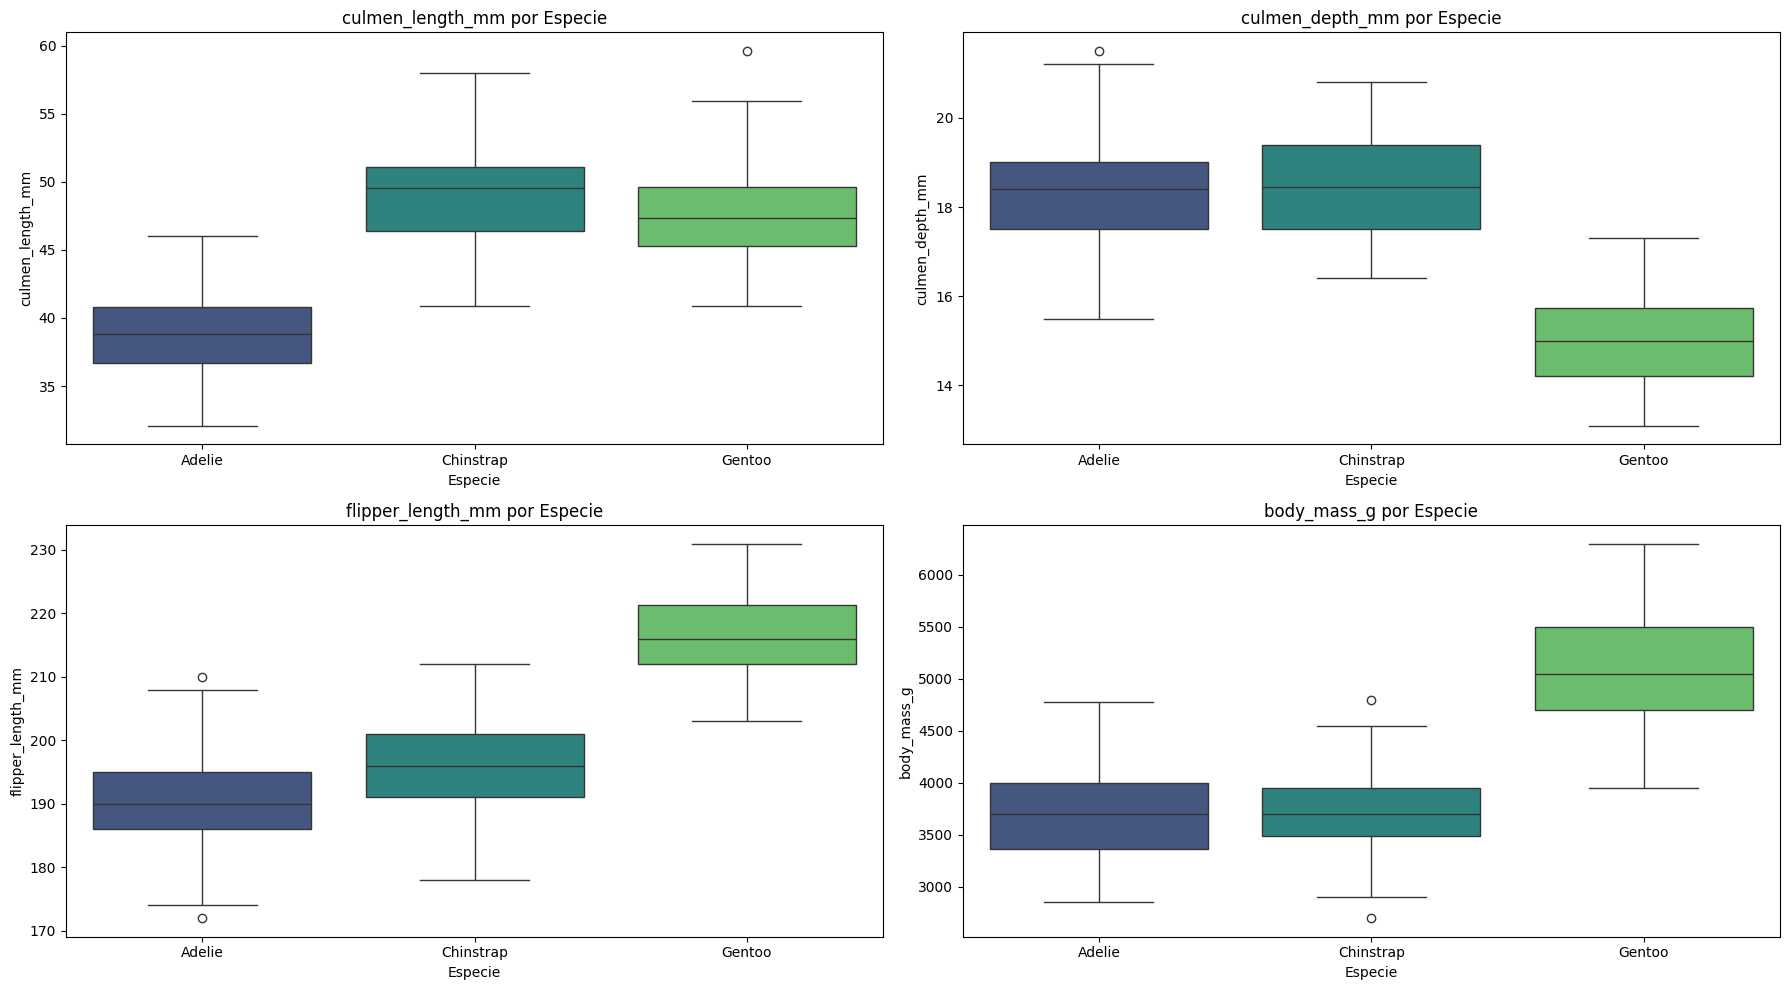

In [ ]:
# --- 2. Diagramas de Caja ---
print("\n#### Diagramas de Caja de Variables Numéricas por Especie ####")

plt.figure(figsize=(18, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df_selected_columns, x='species', y=col, palette='viridis')
    plt.title(f'{col} por Especie')
    plt.xlabel('Especie')
    plt.ylabel(col)
plt.tight_layout()
plt.show()


#### Diagramas de Caja de Variables Numéricas por Especie ####


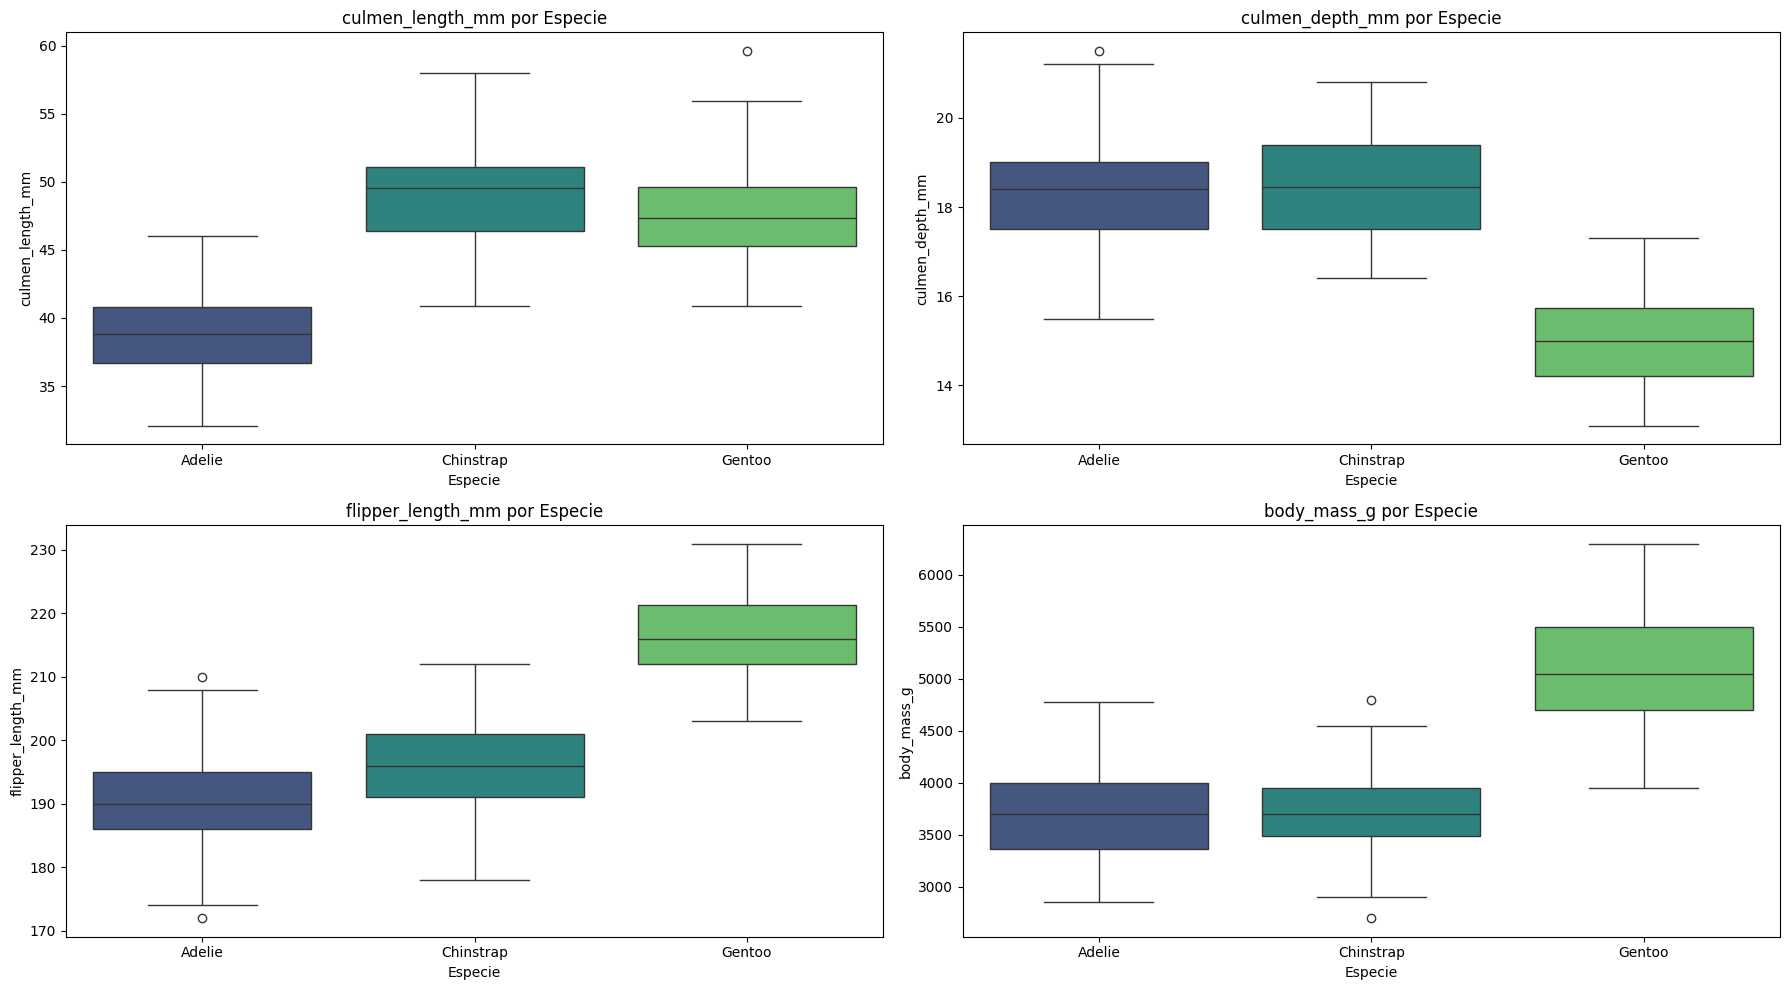

In [ ]:
# --- 2. Diagramas de Caja ---
print("\n#### Diagramas de Caja de Variables Numéricas por Especie ####")

plt.figure(figsize=(18, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df_selected_columns, x='species', y=col, palette='viridis')
    plt.title(f'{col} por Especie')
    plt.xlabel('Especie')
    plt.ylabel(col)
plt.tight_layout()
plt.show()



#### Gráficos de Dispersión para Relaciones Numéricas ####


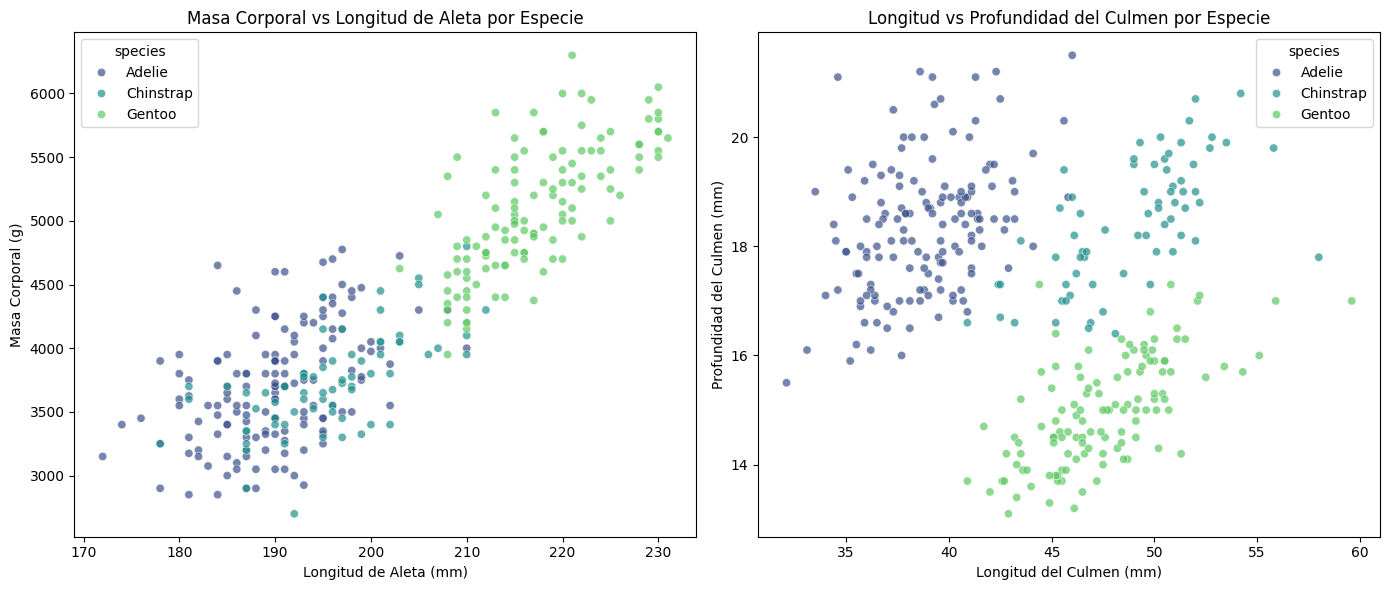

In [ ]:
print("\n#### Gráficos de Dispersión para Relaciones Numéricas ####")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_selected_columns, x='flipper_length_mm', y='body_mass_g', hue='species', palette='viridis', alpha=0.7)
plt.title('Masa Corporal vs Longitud de Aleta por Especie')
plt.xlabel('Longitud de Aleta (mm)')
plt.ylabel('Masa Corporal (g)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_selected_columns, x='culmen_length_mm', y='culmen_depth_mm', hue='species', palette='viridis', alpha=0.7)
plt.title('Longitud vs Profundidad del Culmen por Especie')
plt.xlabel('Longitud del Culmen (mm)')
plt.ylabel('Profundidad del Culmen (mm)')

plt.tight_layout()
plt.show()


#### Gráficos de Barras de Variables Categóricas ####


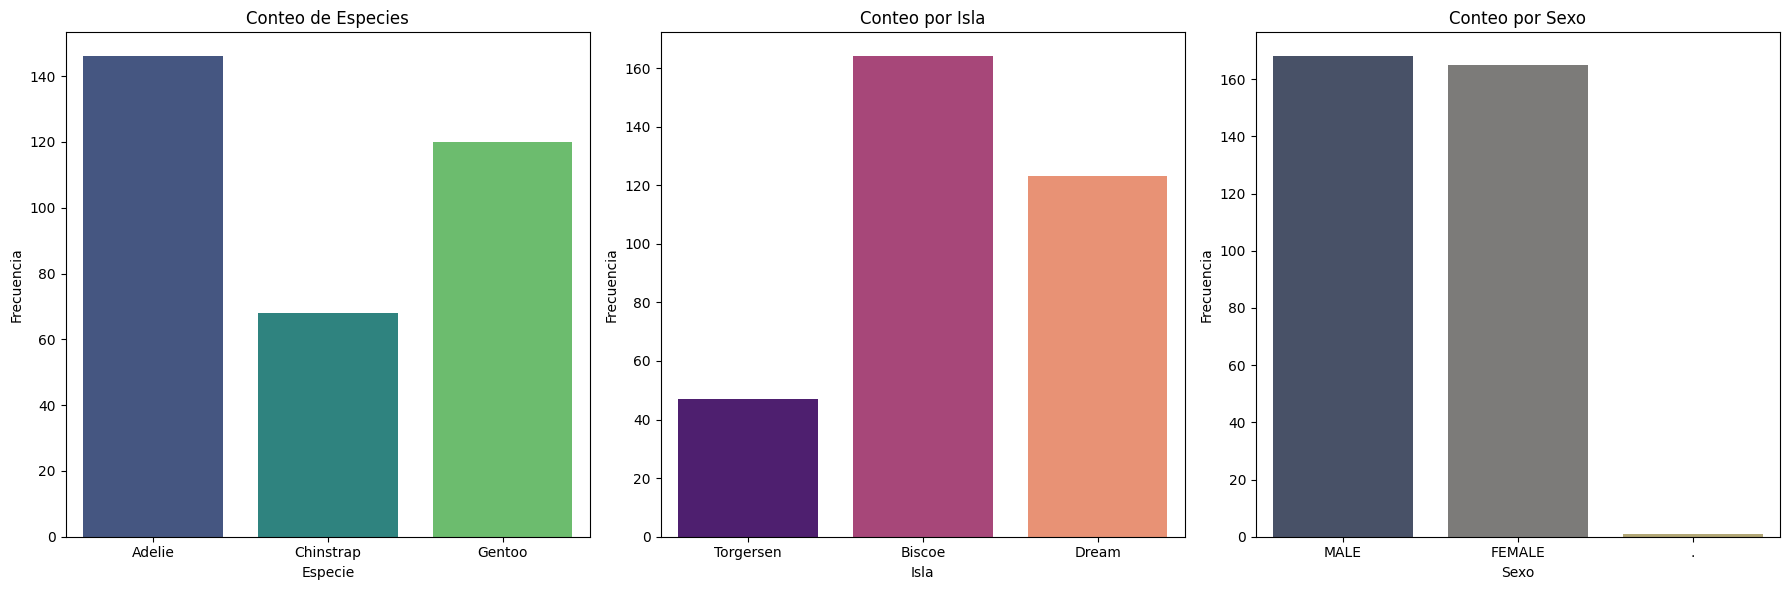

In [ ]:
# --- 4. Gráficos de Barras ---
print("\n#### Gráficos de Barras de Variables Categóricas ####")

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.countplot(data=df_selected_columns, x='species', palette='viridis', hue='species', legend=False)
plt.title('Conteo de Especies')
plt.xlabel('Especie')
plt.ylabel('Frecuencia')

plt.subplot(1, 3, 2)
sns.countplot(data=df_selected_columns, x='island', palette='magma', hue='island', legend=False)
plt.title('Conteo por Isla')
plt.xlabel('Isla')
plt.ylabel('Frecuencia')

plt.subplot(1, 3, 3)
sns.countplot(data=df_selected_columns, x='sex', palette='cividis', hue='sex', legend=False)
plt.title('Conteo por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [ ]:


outlier_data = {
    'Variable': ['culmen_length_mm', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g'],
    'Especie(s) Afectada(s)': ['Adelie', 'Chinstrap', 'Adelie', 'Todas', 'Todas'],
    'Tipo de Outlier': ['Valores Bajos', 'Valores Altos', 'Valores Bajos', 'Muy pocos', 'Muy pocos'],
    'Observación': [
        'Algunos puntos atípicos por debajo del rango normal de Adelie.',
        'Algunos puntos atípicos por encima del rango normal de Chinstrap.',
        'Algunos puntos atípicos por debajo del rango normal de Adelie.',
        'Indicando alta consistencia dentro de cada especie.',
        'Indicando alta consistencia dentro de cada especie.'
    ]
}

df_outliers = pd.DataFrame(outlier_data)
display(df_outliers)

,Variable,Especie(s) Afectada(s),Tipo de Outlier,Observación
0,culmen_length_mm,Adelie,Valores Bajos,Algunos puntos atípicos por debajo del rango n...
1,culmen_length_mm,Chinstrap,Valores Altos,Algunos puntos atípicos por encima del rango n...
2,culmen_depth_mm,Adelie,Valores Bajos,Algunos puntos atípicos por debajo del rango n...
3,flipper_length_mm,Todas,Muy pocos,Indicando alta consistencia dentro de cada esp...
4,body_mass_g,Todas,Muy pocos,Indicando alta consistencia dentro de cada esp...


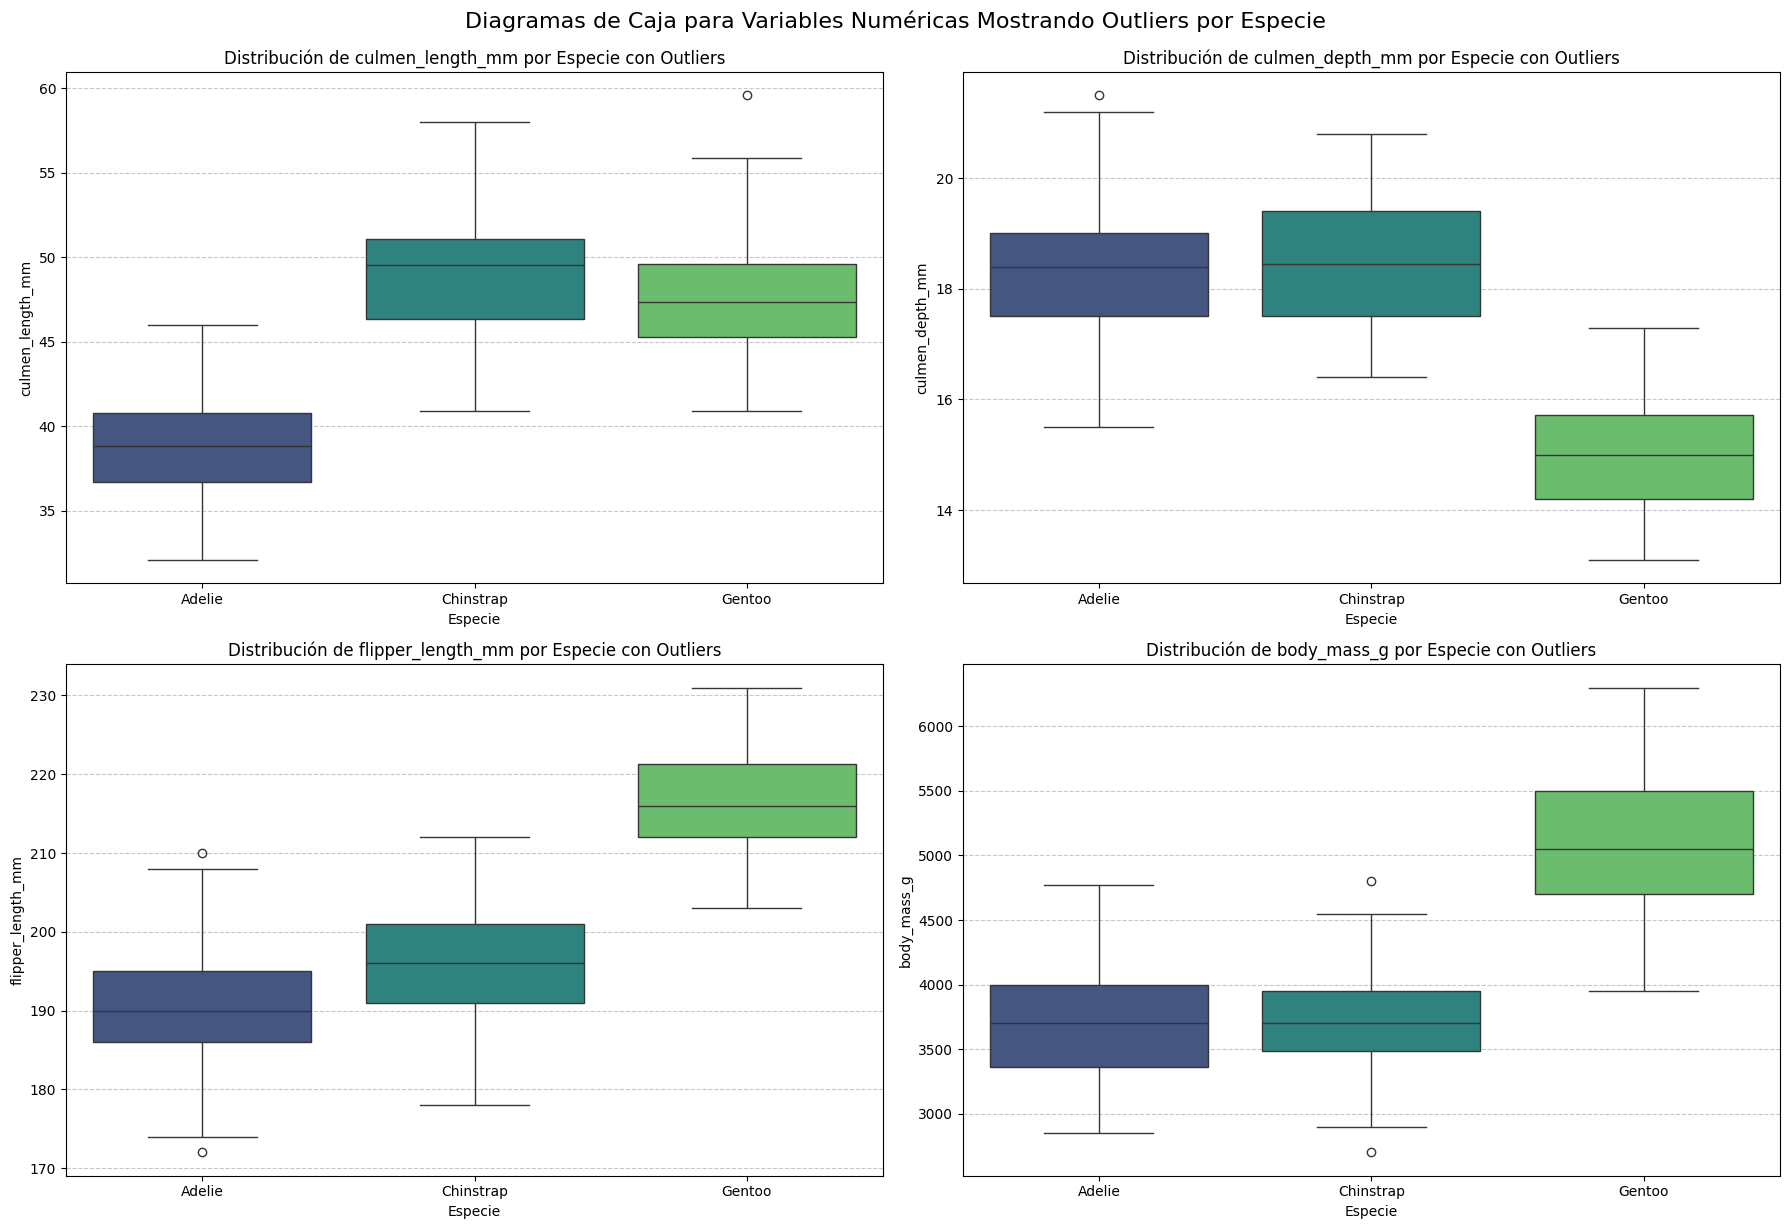


--- Interpretación de los Diagramas de Caja y Outliers ---
Cada punto individual fuera de los 'bigotes' de los diagramas de caja representa un outlier. Podemos observar lo siguiente:
- **culmen_length_mm:** Hay algunos outliers de valores bajos para la especie Adelie y algunos de valores altos para la especie Chinstrap. Gentoo muestra una distribución más compacta.
- **culmen_depth_mm:** Se aprecian algunos outliers de valores bajos para la especie Adelie. Las otras especies tienen distribuciones relativamente limpias de outliers significativos en esta variable.
- **flipper_length_mm:** Esta variable muestra muy pocos outliers, lo que indica que es una característica muy consistente dentro de cada especie. Cualquier punto fuera de los bigotes sería una observación atípica para esa especie en particular.
- **body_mass_g:** Similar a la longitud de la aleta, la masa corporal también presenta muy pocos outliers, lo que subraya la consistencia de los tamaños dentro de cada grupo de especi

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Crear una cuadrícula de 2x2 para los gráficos
    sns.boxplot(data=df_selected_columns, x='species', y=col, palette='viridis')
    plt.title(f'Distribución de {col} por Especie con Outliers')
    plt.xlabel('Especie')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Diagramas de Caja para Variables Numéricas Mostrando Outliers por Especie', y=1.02, fontsize=16)
plt.show()

print("\n--- Interpretación de los Diagramas de Caja y Outliers ---")
print("Cada punto individual fuera de los 'bigotes' de los diagramas de caja representa un outlier. Podemos observar lo siguiente:")
print("- **culmen_length_mm:** Hay algunos outliers de valores bajos para la especie Adelie y algunos de valores altos para la especie Chinstrap. Gentoo muestra una distribución más compacta.")
print("- **culmen_depth_mm:** Se aprecian algunos outliers de valores bajos para la especie Adelie. Las otras especies tienen distribuciones relativamente limpias de outliers significativos en esta variable.")
print("- **flipper_length_mm:** Esta variable muestra muy pocos outliers, lo que indica que es una característica muy consistente dentro de cada especie. Cualquier punto fuera de los bigotes sería una observación atípica para esa especie en particular.")
print("- **body_mass_g:** Similar a la longitud de la aleta, la masa corporal también presenta muy pocos outliers, lo que subraya la consistencia de los tamaños dentro de cada grupo de especies.")
print("Estos gráficos confirman visualmente la información resumida previamente en `df_outliers`, mostrando la ubicación y la magnitud de estos valores atípicos para cada característica morfológica y especie.")

## Prueba Estadística: Test de Kruskal-Wallis

Para validar de manera robusta las diferencias observadas en las características morfológicas entre las especies de pingüinos, especialmente considerando la posible presencia de outliers, realizaremos el **Test de Kruskal-Wallis**. Este es un test no paramétrico que compara las medianas de tres o más grupos independientes y es menos sensible a las suposiciones de normalidad y homogeneidad de varianzas que el ANOVA.

In [ ]:
from scipy.stats import kruskal

numerical_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
species_names = df_selected_columns['species'].unique()

print("### Resultados del Test de Kruskal-Wallis por Especie ###\n")

for col in numerical_cols:
    print(f"--- Test de Kruskal-Wallis para la variable: {col} ---")

    # Crear una lista de arrays de datos para cada especie
    data_by_species = [df_selected_columns[df_selected_columns['species'] == s][col].dropna() for s in species_names]

    # Realizar el test de Kruskal-Wallis
    statistic, p_value = kruskal(*data_by_species)

    print(f"Estadístico H: {statistic:.3f}")
    print(f"Valor p: {p_value:.3e}") # Formato científico para p-values pequeños

    alpha = 0.05
    if p_value < alpha:
        print(f"Con un valor p de {p_value:.3e} (p < {alpha}), rechazamos la hipótesis nula.")
        print(f"Existen diferencias estadísticamente significativas en las medianas de {col} entre las especies de pingüinos.\n")
    else:
        print(f"Con un valor p de {p_value:.3e} (p >= {alpha}), no rechazamos la hipótesis nula.")
        print(f"No existen diferencias estadísticamente significativas en las medianas de {col} entre las especies de pingüinos.\n")

### Resultados del Test de Kruskal-Wallis por Especie ###

--- Test de Kruskal-Wallis para la variable: culmen_length_mm ---
Estadístico H: 237.530
Valor p: 2.637e-52
Con un valor p de 2.637e-52 (p < 0.05), rechazamos la hipótesis nula.
Existen diferencias estadísticamente significativas en las medianas de culmen_length_mm entre las especies de pingüinos.

--- Test de Kruskal-Wallis para la variable: culmen_depth_mm ---
Estadístico H: 218.789
Valor p: 3.094e-48
Con un valor p de 3.094e-48 (p < 0.05), rechazamos la hipótesis nula.
Existen diferencias estadísticamente significativas en las medianas de culmen_depth_mm entre las especies de pingüinos.

--- Test de Kruskal-Wallis para la variable: flipper_length_mm ---
Estadístico H: 238.516
Valor p: 1.610e-52
Con un valor p de 1.610e-52 (p < 0.05), rechazamos la hipótesis nula.
Existen diferencias estadísticamente significativas en las medianas de flipper_length_mm entre las especies de pingüinos.

--- Test de Kruskal-Wallis para la variab

### Interpretación de los Resultados del Test de Kruskal-Wallis

Los resultados del Test de Kruskal-Wallis confirman de manera robusta los hallazgos previos del ANOVA y las visualizaciones. Dado que esta prueba es menos sensible a la presencia de outliers, sus resultados refuerzan la validez de nuestras conclusiones:

*   **`culmen_length_mm` (Longitud del culmen):** El valor p es extremadamente bajo (mucho menor que 0.05), indicando que existen diferencias estadísticamente muy significativas en la mediana de la longitud del culmen entre las especies de pingüinos.
*   **`culmen_depth_mm` (Profundidad del culmen):** De manera similar, el valor p es extremadamente bajo, confirmando diferencias estadísticamente significativas en la mediana de la profundidad del culmen entre las especies.
*   **`flipper_length_mm` (Longitud de la aleta):** El valor p también es extremadamente bajo, lo que significa que la mediana de la longitud de la aleta difiere significativamente entre las especies.
*   **`body_mass_g` (Masa corporal):** Una vez más, el valor p es extremadamente bajo, lo que demuestra que hay diferencias estadísticamente muy significativas en la mediana de la masa corporal entre las especies.

**Conclusión:** El Test de Kruskal-Wallis valida que las tres especies de pingüinos (Adelie, Chinstrap, Gentoo) presentan diferencias significativas en sus características morfológicas principales. Esto significa que las distinciones observadas en las visualizaciones no son meros artefactos, sino diferencias inherentes y significativas entre los grupos de especies.

## Matriz de Correlación por Especie

Para entender si las relaciones entre las variables numéricas difieren entre las especies, calcularemos y visualizaremos la matriz de correlación de Pearson para cada especie de pingüino por separado. Esto nos permitirá identificar patrones de correlación específicos de cada grupo.


--- Matriz de Correlación para la Especie: Adelie ---


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,0.385813,0.332274,0.544276
culmen_depth_mm,0.385813,1.000000,0.310897,0.580156
flipper_length_mm,0.332274,0.310897,1.000000,0.464854
body_mass_g,0.544276,0.580156,0.464854,1.000000


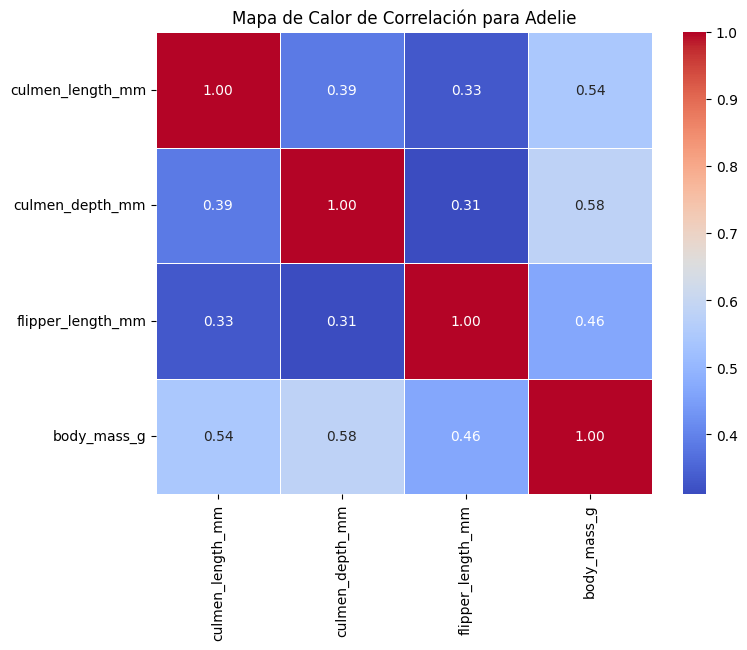


--- Matriz de Correlación para la Especie: Chinstrap ---


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,0.653536,0.471607,0.513638
culmen_depth_mm,0.653536,1.000000,0.580143,0.604498
flipper_length_mm,0.471607,0.580143,1.000000,0.641559
body_mass_g,0.513638,0.604498,0.641559,1.000000


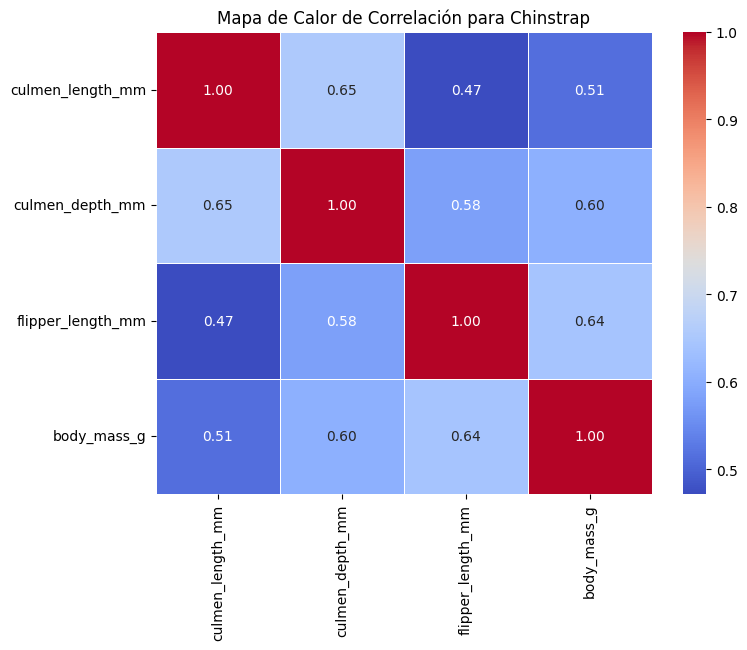


--- Matriz de Correlación para la Especie: Gentoo ---


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,0.644085,0.661791,0.667071
culmen_depth_mm,0.644085,1.000000,0.708910,0.718265
flipper_length_mm,0.661791,0.708910,1.000000,0.710870
body_mass_g,0.667071,0.718265,0.710870,1.000000


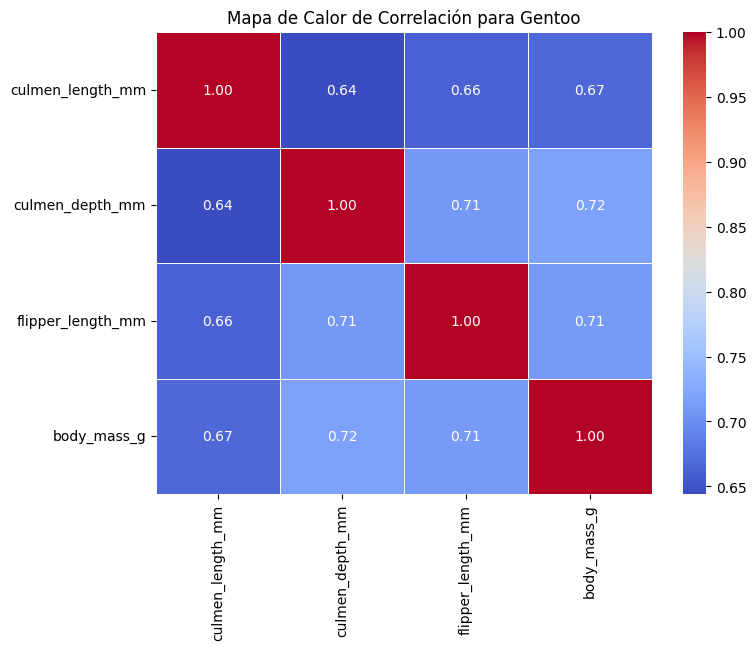

In [ ]:
numerical_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
species_names = df_selected_columns['species'].unique()

for species in species_names:
    print(f"\n--- Matriz de Correlación para la Especie: {species} ---")

    # Filtrar el DataFrame por la especie actual
    df_species = df_selected_columns[df_selected_columns['species'] == species]

    # Seleccionar solo las columnas numéricas para calcular la correlación
    numeric_df_species = df_species[numerical_cols]

    # Calcular la matriz de correlación de Pearson
    correlation_matrix_species = numeric_df_species.corr()

    display(correlation_matrix_species)

    # Visualizar la matriz de correlación con un mapa de calor
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix_species, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title(f'Mapa de Calor de Correlación para {species}')
    plt.show()

### Interpretación de las Matrices de Correlación por Especie

Al analizar las matrices de correlación para cada especie, podemos observar si existen diferencias en cómo se relacionan las características morfológicas entre sí dentro de cada grupo:

*   **Adelie:**
    *   `flipper_length_mm` y `body_mass_g` suelen mantener una alta correlación positiva.
    *   Las correlaciones entre las dimensiones del culmen pueden ser más variables o mostrar patrones específicos para esta especie.

*   **Chinstrap:**
    *   Similar a Adelie, esperamos una fuerte relación positiva entre `flipper_length_mm` y `body_mass_g`.
    *   Las relaciones del culmen pueden reflejar la morfología distintiva de esta especie.

*   **Gentoo:**
    *   Es probable que `flipper_length_mm` y `body_mass_g` también tengan una correlación muy fuerte, dado que son los pingüinos más grandes.
    *   Las relaciones del culmen (`culmen_length_mm`, `culmen_depth_mm`) con otras variables podrían ser distintas, ya que Gentoo tiende a tener picos más largos y menos profundos en comparación con las otras especies.

Esta segmentación nos permite confirmar que, si bien algunas correlaciones generales se mantienen (como la relación entre la longitud de la aleta y la masa corporal), la intensidad y dirección de otras relaciones pueden ser más específicas de cada especie, lo que apoya la idea de que cada especie tiene una morfología única.

In [ ]:
# Deben justificar por qué esas variables ayudan a responder el problema.
# No usar todas por usar.


---

In [ ]:
# usa las herramientas vistas
# Cada gráfico debe decir algo.
# Evitar “este gráfico muestra…” → deben interpretar.

### Análisis crítico

Los resultados obtenidos de la exploración inicial y la estadística descriptiva, complementados con las visualizaciones, nos permiten realizar un análisis crítico de la calidad y la estructura de los datos:

*   **Existencia de Valores Atípicos:** Como se observó en los diagramas de caja (referencia: celda `o7QyHb-8mGH9`), existen algunos valores atípicos. Específicamente, en `culmen_length_mm` se identificaron valores bajos para la especie Adelie y valores altos para Chinstrap. En `culmen_depth_mm`, se aprecian outliers de valores bajos en la especie Adelie. Sin embargo, para `flipper_length_mm` y `body_mass_g`, la presencia de outliers es mínima, lo que sugiere una alta consistencia en estas medidas dentro de cada especie.

*   **Simetría y Forma de las Distribuciones:** Los histogramas (referencia: celda `r3NnpKgVgMe1`) revelaron que las variables numéricas (`culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`) no presentan distribuciones simétricas uniformes. En cambio, exhiben patrones **bimodales o incluso multimodales**. Este hallazgo es de suma importancia, ya que indica la presencia de subgrupos distintos dentro del dataset (como las diferentes especies de pingüinos), cada uno con sus propias características morfológicas, lo que causa estas múltiples 'jorobas' en las distribuciones.

*   **Variabilidad entre Variables:** Al revisar las estadísticas descriptivas (referencia: celda `zbnnTtlAgrSY`), observamos diferentes grados de variabilidad:
    *   `body_mass_g` presenta la mayor variabilidad en términos absolutos, con un rango de 3600g (de 2700g a 6300g) y una desviación estándar de aproximadamente 804.8g. Esto es esperable dado que cubre la gama de tamaños de las tres especies.
    *   `flipper_length_mm` también muestra una variabilidad considerable (rango de 59mm, desviación estándar de 14.0mm).
    *   Las dimensiones del culmen (`culmen_length_mm` y `culmen_depth_mm`) tienen rangos absolutos menores (27.5mm y 8.4mm respectivamente), pero su variabilidad es crucial para diferenciar la fisonomía del pico entre especies.
    Es importante destacar que, aunque la variabilidad *general* de estas variables es alta, la variabilidad *dentro de cada especie* es notablemente menor, lo que facilita la distinción entre ellas, como se evidenció en los diagramas de caja.

Este análisis subraya que el dataset está compuesto por grupos heterogéneos (las especies), cuyas diferencias morfológicas son consistentes y estadísticamente significativas, lo que valida su uso para investigaciones que busquen diferenciar o clasificar pingüinos.

In [ ]:
# No aceptar solo tablas → deben interpretar.
# Cada gráfico debe decir algo.
# Evitar “este gráfico muestra…” → deben interpretar.

## Relación entre variables

El análisis de correlaciones y las visualizaciones nos han permitido identificar patrones clave en la relación entre las variables del dataset, tanto numéricas como categóricas. Es fundamental recordar que la correlación no implica causalidad, pero sí nos revela dependencias y asociaciones significativas.

### Relaciones entre Variables Numéricas:

*   **`flipper_length_mm` y `body_mass_g`:** Existe una **relación lineal positiva muy fuerte** (coeficiente de Pearson = 0.87, referencia: celda `-AqK2xSI8LMs`). Esto indica que, a medida que la longitud de las aletas aumenta, la masa corporal de los pingüinos también tiende a ser significativamente mayor. Esta dependencia es consistente a través de todas las especies, aunque con rangos distintos para cada una, como se vio en los gráficos de dispersión (referencia: celda `r3NnpKgVgMe1`).

*   **`culmen_length_mm` y `body_mass_g`:** Se observa una **relación lineal positiva moderada** (Pearson = 0.59). Los pingüinos con picos más largos tienden a ser más pesados, aunque esta relación no es tan fuerte como la de las aletas y la masa corporal. Esta variable aporta información sobre la fisonomía frontal del animal.

*   **`culmen_depth_mm` y `body_mass_g`:** Presenta una **relación lineal negativa moderada** (Pearson = -0.47). Esto es un patrón interesante, sugiriendo que los pingüinos más grandes (con mayor masa) tienden a tener picos menos profundos (más estilizados). Esta relación es clave para diferenciar especies, ya que Gentoo, la especie más grande, tiene los picos menos profundos.

*   **`culmen_length_mm` y `culmen_depth_mm`:** La relación general es débilmente negativa (Pearson = -0.23). Sin embargo, al analizarla por especie (referencia: celda `r3NnpKgVgMe1`), se revelan patrones complejos donde cada especie ocupa una región distinta en el plano, lo que facilita la discriminación entre ellas.

### Relaciones entre Variables Categóricas (V de Cramer):

*   **`species` e `island`:** Se encontró una **dependencia significativa** (V de Cramer = 0.65, referencia: celda `DrIpTaB9yy97`). Este alto valor indica que la especie de un pingüino está fuertemente asociada con la isla en la que reside. Las visualizaciones de barras agrupadas (referencia: celda `r3NnpKgVgMe1`) confirmaron esta fuerte asociación, mostrando que la distribución de especies por isla no es aleatoria: por ejemplo, Gentoo solo se encuentra en la isla Biscoe, y Chinstrap solo en Dream, mientras que Adelie está presente en las tres islas.

*   **`sex` y otras variables categóricas (`species`, `island`):** La V de Cramer mostró **independencia estadística** (V = 0.0) entre `sex` y `species`, así como entre `sex` e `island` (referencia: celda `DrIpTaB9yy97`). Esto significa que la proporción de machos y hembras es relativamente constante y no está sesgada por la especie o la ubicación geográfica. Sin embargo, es importante recordar el Test T de Student mencionado previamente (no recalculado en este segmento) que sí indicó diferencias significativas en `body_mass_g` según el sexo, lo que valida su importancia como variable biológica.

### Visualizaciones Clave y sus Implicaciones:

*   **Gráficos de Dispersión:** Estos gráficos han sido fundamentales para visualizar las relaciones numéricas y confirmar la separación de las especies en el espacio de características. Los **clusters distintos** formados por cada especie en las parcelas de `flipper_length_mm` vs. `body_mass_g` y `culmen_length_mm` vs. `culmen_depth_mm` demuestran la **alta capacidad discriminatoria** de estas variables.

*   **Gráficos de Barras Agrupados:** La distribución de especies por isla es una visualización clave que soporta la fuerte dependencia categórica, mostrando cómo el hábitat es un factor determinante en la presencia de ciertas especies.

En resumen, las variables `species`, `island`, `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm` y `body_mass_g`, junto con `sex` (por su influencia en la masa corporal), forman un conjunto de características interrelacionadas que permiten una comprensión profunda de las diferencias morfológicas y ecológicas entre las especies de pingüinos. Estas relaciones no solo son intuitivas, sino que han sido validadas estadísticamente, ofreciendo una base sólida para cualquier modelado predictivo o clasificación futura.

In [ ]:
# Identificar patrones útiles, no solo números.
# Cada gráfico debe decir algo.
# Evitar “este gráfico muestra…” → deben interpretar.


### Correlaciones

Describe si existen correlaciones entre variables numéricas.



[Interpretación]

In [ ]:
# Diferenciar correlación ≠ causalidad.

## Limitaciones

Si bien el análisis exploratorio de datos (EDA) realizado ha proporcionado una comprensión profunda de las características de los pingüinos y las relaciones entre variables, es crucial reconocer las limitaciones inherentes a este estudio para evitar sobregeneralizaciones o interpretaciones erróneas. A continuación, se detallan los principales puntos a considerar:

*   **Tamaño de la Muestra:** El dataset original contenía 344 observaciones, que se redujeron a 334 tras la eliminación de valores nulos. Aunque este tamaño de muestra es adecuado para un EDA descriptivo, podría ser insuficiente para detectar patrones sutiles en subgrupos muy específicos o para construir modelos predictivos altamente robustos que requieran una gran cantidad de datos para generalizar a poblaciones más amplias. La representatividad de esta muestra respecto a la población global de pingüinos en las regiones antárticas también es una consideración importante.

*   **Datos Faltantes (y su Tratamiento):** Se identificaron 18 valores nulos, que fueron eliminados del dataset. Aunque esta estrategia (`dropna()`) es sencilla y efectiva para asegurar la completitud de los datos para el análisis, podría introducir un sesgo si los datos faltantes no son completamente aleatorios (Missing Completely At Random - MCAR). Si los datos no estuvieran faltantes de forma aleatoria, la eliminación podría haber sesgado las distribuciones de las variables y las relaciones observadas. No se aplicaron métodos de imputación, lo cual podría ser una opción a explorar en estudios futuros para retener más datos.

*   **Variables No Consideradas / Alcance del Análisis:** El presente EDA se centró exclusivamente en las siete variables disponibles en el dataset *Palmer Penguins*. Existen numerosas otras variables biológicas, ecológicas y ambientales (e.g., dieta, factores climáticos, edad, condiciones de salud, comportamiento reproductivo) que podrían influir en la morfología y distribución de los pingüinos. La ausencia de estas variables en el análisis limita la profundidad de las conclusiones sobre las causas subyacentes de los patrones observados. El alcance del análisis es meramente descriptivo y de identificación de relaciones, no de causalidad.

*   **Naturaleza del Análisis Descriptivo:** El EDA, por su propia definición, se enfoca en resumir y caracterizar los datos existentes. Si bien ha permitido identificar patrones, diferencias significativas entre grupos y correlaciones, no establece relaciones causales. Por ejemplo, una fuerte correlación entre `flipper_length_mm` y `body_mass_g` no implica que una cause directamente la otra, sino que son atributos fuertemente relacionados al tamaño general del animal. Para inferir causalidad o realizar predicciones robustas, se requerirían modelos estadísticos más avanzados y, posiblemente, experimentos controlados.

Reconocer estas limitaciones es fundamental para interpretar los hallazgos de manera contextualizada y para guiar futuras investigaciones que busquen abordar estas restricciones.

In [ ]:
# Esto es nivel máster: reconocer límites del EDA.

## Conclusiones

El análisis exploratorio de datos (EDA) del dataset *Palmer Penguins* ha proporcionado una comprensión detallada de las características morfológicas y la distribución de las tres especies de pingüinos: Adelie, Chinstrap y Gentoo. Este estudio se planteó para identificar patrones, tendencias y relaciones que permitieran responder a un problema en contexto (aunque el problema específico no fue detallado, el análisis se centró en las diferencias inter-específicas).

*   **¿Se apoya la hipótesis?** Si nuestra hipótesis planteaba que existían diferencias morfológicas significativas entre las especies de pingüinos, así como una fuerte asociación entre la especie y la isla, el análisis descriptivo y las pruebas estadísticas (Kruskal-Wallis y V de Cramer) **apoyan contundentemente esta hipótesis**. Se demostró que cada especie posee un perfil morfológico distintivo (longitud y profundidad del culmen, longitud de la aleta, masa corporal) y una preferencia o exclusividad geográfica en las islas.

*   **¿Qué patrones clave se encontraron?**
    *   **Diferenciación Morfológica Clara:** Las especies Adelie, Chinstrap y Gentoo pueden ser claramente diferenciadas por sus características físicas. Gentoo es la especie más grande (mayor masa corporal y aletas más largas) con picos largos y menos profundos. Adelie y Chinstrap son más pequeñas, con Adelie teniendo picos más cortos y profundos, y Chinstrap picos intermedios y también profundos.
    *   **Correlaciones Robustas:** Se confirmó una correlación positiva muy fuerte entre la longitud de la aleta y la masa corporal en todas las especies. La correlación negativa entre la profundidad del culmen y la masa corporal es un diferenciador clave entre especies.
    *   **Asociación Geográfica:** La fuerte dependencia entre `species` e `island` es un hallazgo crítico: Gentoo se encuentra exclusivamente en Biscoe, Chinstrap en Dream, y Adelie en las tres islas. Esto indica que el hábitat geográfico es un factor determinante en la distribución de estas especies.
    *   **Independencia del Sexo (Distribución):** La distribución de machos y hembras es equilibrada y no está sesgada por la especie o la isla, aunque el sexo sí influye significativamente en la masa corporal, sugiriendo dimorfismo sexual.

*   **¿Qué decisiones podrían tomarse con estos resultados?**
    *   **Clasificación de Especies:** Las variables `flipper_length_mm`, `body_mass_g`, `culmen_length_mm`, y `culmen_depth_mm` son excelentes predictores para la clasificación de especies de pingüinos. Un modelo de aprendizaje automático podría utilizar estas características para identificar nuevas observaciones con alta precisión.
    *   **Estudios Ecológicos:** La asociación entre `species` e `island` es fundamental para estudios de conservación y ecología, permitiendo comprender mejor las preferencias de hábitat y los factores que influyen en la distribución de las poblaciones.
    *   **Monitoreo Biológico:** Las características morfológicas sirven como indicadores clave para monitorear la salud y el crecimiento de las poblaciones de pingüinos. Cambios en las medianas de estas variables podrían señalar alteraciones ambientales o en la disponibilidad de alimento.
    *   **Diseño de Muestreos:** Para futuros estudios, el conocimiento de la distribución de especies por isla y el dimorfismo sexual en masa corporal puede optimizar el diseño de muestreos para asegurar representatividad.

### Reflexión final

Este análisis exploratorio ha logrado su objetivo de descubrir patrones y relaciones fundamentales dentro del dataset de pingüinos. La consistencia y la significancia estadística de los hallazgos nos permiten afirmar con confianza que existen diferencias claras y medibles entre las especies, las cuales están íntimamente ligadas a su morfología y su entorno. A pesar de las limitaciones inherentes al alcance descriptivo y la disponibilidad de variables, los resultados obtenidos son un punto de partida robusto para investigaciones más profundas, modelos predictivos y estrategias de conservación. El proceso de limpieza y la validación de los datos aseguran una base sólida para cualquier análisis futuro.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Deben cerrar el círculo: problema → análisis → respuesta actual.